# 📊 Headhunting & Issuing Data Visualization & Statistical Analytics / 終末地卡池數據視覺化與統計分析

Welcome! This notebook is dedicated to parsing, analyzing, and visualizing the CSV data generated by the Simulation Module. You can use search shortcuts or leverage native outline views for seamless navigation.

歡迎使用視覺化與統計分析模組！本檔案專用於解析、分析並將模擬模組產出的 CSV 數據繪製成圖表。您可利用快捷搜尋或搭配大綱面板快速定位指定區塊。

---

**🇺🇸 English Version - Structure Overview**
***

> 💡 **Navigation Hint**:
> * **Keyboard Search**: Press `Ctrl + F` (Mac: `Cmd + F`) and search for any section tag (e.g., `mode-1` or `[MODE-1]`) or title below to jump directly to that section.
> * **Native Outline**: You can also use the native **Outline** panel in VS Code for smooth section hopping.

* 🛠️ **`[MODE-0]` 0. Dependencies, Plot Settings & Gacha Quota Conversion / 基礎套件、繪圖設定與角色池各種配額轉換**
* 🎯 **`[MODE-1]` 1. Headhunting Banner - First Acquisition Analysis & Charts / 首次獲得限定角色模擬結果之統計與視覺化圖表**
* 👑 **`[MODE-2]` 2. Headhunting Banner - Full Potential Analysis & Charts / 滿潛限定角色模擬結果之統計與視覺化圖表**
* 📊 **`[MODE-3]` 3. Special Analysis - Arsenal Ticket & Arsenal Issues Conversion Charts / 武庫配額獲取與武器申領次數轉換模擬結果之統計與視覺化圖表**
* ⚔️ **`[MODE-4]` 4. Arsenal Issues - First Acquisition Analysis & Charts / 首次獲得機率提升武器模擬結果之統計與視覺化圖表**
* ⚙️ **`[MODE-5]` 5. Arsenal Issues - Full Potential Analysis & Charts / 滿潛機率提升武器模擬結果之統計與視覺化圖表**

[🎲 Go to Simulation Module](./simulation.ipynb)

---

**🇹🇼 繁體中文版 - 架構總覽**
***

> 💡 **導覽提示**：
> * **快捷搜尋**：按 `Ctrl + F`（Mac 為 `Cmd + F`）搜尋下方選單中的任意標籤（例如 `mode-1` 或 `[MODE-1]`）或完整標題，即可秒跳至指定區塊。
> * **原生大綱**：亦可善用 VS Code 編輯器左側內建的大綱（Outline）面板進行章節切換。

* 🛠️ **`[MODE-0]` 0. Dependencies, Plot Settings & Gacha Quota Conversion / 基礎套件、繪圖設定與角色池各種配額轉換**
* 🎯 **`[MODE-1]` 1. Headhunting Banner - First Acquisition Analysis & Charts / 首次獲得限定角色模擬結果之統計與視覺化圖表**
* 👑 **`[MODE-2]` 2. Headhunting Banner - Full Potential Analysis & Charts / 滿潛限定角色模擬結果之統計與視覺化圖表**
* 📊 **`[MODE-3]` 3. Special Analysis - Arsenal Ticket & Arsenal Issues Conversion Charts / 武庫配額獲取與武器申領次數轉換模擬結果之統計與視覺化圖表**
* ⚔️ **`[MODE-4]` 4. Arsenal Issues - First Acquisition Analysis & Charts / 首次獲得機率提升武器模擬結果之統計與視覺化圖表**
* ⚙️ **`[MODE-5]` 5. Arsenal Issues - Full Potential Analysis & Charts / 滿潛機率提升武器模擬結果之統計與視覺化圖表**

[🎲 切換至數據模擬器模組](./simulation.ipynb)

## [MODE-0] 0. Dependencies, Plot Settings & Gacha Quota Conversion / 基礎套件、繪圖設定與角色池各種配額轉換

**🇺🇸 English Version**
***

**🛠️ Environment Dependencies, Global Visual Configuration & Idempotent File Management**
* **Data Processing & Path Management**: Imports `math`, `numpy`, and `pandas` for numerical operations and data transformations; utilizes `pathlib.Path` for dynamic directory handling with `DATA_DIR` (`sim_data`) for simulation inputs and `IMAGE_DIR` (`images`) for output figures. Automatically creates the root output directory idempotently (`IMAGE_DIR.mkdir(parents=True, exist_ok=True)`).
* **Visualization & Plot Styling**: Integrates `matplotlib.pyplot` and `seaborn`. Configures a clean `white` theme, sets default display resolution to `120 DPI`, and enforces `sans-serif` fonts for crisp cross-platform rendering.
* **Professional Color Palette**:
  * **Probability Mass Function (PMF)**: `#2c3e50` (Midnight Blue), applied to individual probability density bars.
  * **Cumulative Distribution Function (CDF)**: `#e74c3c` (Soft Red), applied to cumulative probability trend lines.
  * **Quantile Highlights**: `#27ae60` (Emerald), `#f39c12` (Orange), and `#c0392b` (Pomegranate) for quartile/median annotations.
* **Idempotent Figure Saver (`save_fig`)**:
  * Provides a global helper function to export active figures safely into the `images/` directory at `300 DPI` resolution with `bbox_inches='tight'`.
  * Guarantees idempotence by ensuring parent directories are dynamically created (`file_path.parent.mkdir`) and automatically aligning background settings (`facecolor='white'` or `'none'` if transparent) to prevent environment-dependent file lock conflicts or layout label clipping.

**🔄 Automatic Quota Transformation Engine (`get_char_sim_path_and_transform_quota`)**
Serves as the primary data preprocessor. It reads simulation CSV outputs and settles three sub-product currencies/quotas (`weapon_quota`, `red_quota`, `blue_quota`) based on the simulation context:

1. **Context Detection & Milestone Deduction**:
   * Detects whether the dataset originates from a Full Potential simulation via `(df_name['num_pulls_for_char'] >= 240).any()`.
   * **Milestone Gift Offset**: Every 240 pulls grants 1 free rate-up 6★ operator (`free_gifts = num_pulls_for_char // 240`). Because milestone gifts do not consume gacha resources or generate duplicate tokens, settlement calculates the actual gacha-drawn 6★ count (`actual_pulled_6_star = up_6_star_char - free_gifts + non_6_star_char`).

2. **Sub-product Quota Calculations**:
   * **Baseline Assumption**: Calculations for Red Quota and Blue Quota operate on the assumption that **4★ and 5★ operators are already at Full Potential prior to the pull session**.
   * **Arsenal Ticket (`weapon_quota`)**: Used for Arsenal Issues. Each drawn 6★ yields `2000` points, 5★ yields `200` points, and 4★ yields `20` points (strictly excludes free milestone 6★ gifts).
   * **Red Quota (`red_quota`)**: Guarantee/Redemption certificates. The 2nd+ copy of a 6★ yields `50` points; 5★ yields `10` points; 4★ yields `0`.
   * **Blue Quota (`blue_quota`)**: Integrated Integration Quota. Each 5★ yields `20` points and 4★ yields `5` points.

---

**🇹🇼 繁體中文版**
***

**🛠️ 環境套件、繪圖視覺設定與冪等式圖檔管理**
* **資料處理與路徑管理套件**：匯入 `math`、`numpy`、`pandas` 用於數據運算；使用 `pathlib.Path` 進行動態路徑管理，定義 `DATA_DIR`（`sim_data`）為數據輸入目錄、`IMAGE_DIR`（`images`）為圖檔輸出目錄，並透過 `mkdir(parents=True, exist_ok=True)` 確保目錄自動且冪等（Idempotent）地建立。
* **數據視覺化與圖表樣式**：整合 `matplotlib.pyplot` 與 `seaborn`。圖表主題設定為 `white` 簡潔風格，螢幕預設解析度設為 `120 DPI`，並啟用 `sans-serif` 無襯線字型以確保跨平台圖表文字清晰度。
* **專業調色盤定義**：
  * **機率質量函數（PMF）**：`#2c3e50`（深夜藍 Midnight Blue），用於呈現單點機率分佈柱狀圖。
  * **累積分佈函數（CDF）**：`#e74c3c`（柔和紅 Soft Red），用於繪製累積機率分佈曲線。
  * **分位數標註**：`#27ae60`（翡翠綠）、`#f39c12`（琥珀黃）、`#c0392b`（石榴紅），用於四分位數與中位數標記。
* **冪等式自動存圖函式 (`save_fig`)**：
  * 提供全域繪圖儲存工具，自動將當前圖表以 `300 DPI` 高高畫質與 `bbox_inches='tight'` 自動裁切導出至 `images/` 目錄。
  * 具備完整冪等性（Idempotence）：自動檢查並動態補全父階層目錄（`file_path.parent.mkdir`），並根據 `transparent` 參數動態調配 `facecolor`（透明傳 `'none'`，非透明傳 `'white'`），避免因重複執行或跨平台權限造成寫入異常或圖例遮擋。

**🔄 角色池數據自動轉換函式 (`get_char_sim_path_and_transform_quota`)**
本函式為統計分析的核心資料預處理器，負責讀取角色池模擬產出的 CSV 檔，並根據抽卡情境（首抽 vs 滿潛）進行數據結算，衍生出三種副產物代幣/配額（`weapon_quota`、`red_quota`、`blue_quota`）：

1. **情境判定與滿潛贈送扣除**：
   * 利用 `(df_name['num_pulls_for_char'] >= 240).any()` 自動偵測數據集是否屬「滿潛模式」（極限抽取次數達到或超過 240 抽）。
   * **里程碑贈送扣除**：每滿 240 抽系統會免費贈送 1 隻限定六星角色（`free_gifts = num_pulls_for_char // 240`）。由於贈送的角色不消耗抽取資源，亦不產生任何副產物代幣，因此結算時會先計算出「實際透過卡池抽出的六星總數」(`actual_pulled_6_star = up_6_star_char - free_gifts + non_6_star_char`)。

2. **三大副產物配額（Quota）結算邏輯**：
   * **前提假設**：保障配額與集成配額之結算，皆基於「**4★ 與 5★ 角色在本次抽卡前均已達滿潛**」的基準假設。
   * **武庫配額 (`weapon_quota`)**：用於武器池申領。每抽中 1 隻 6★ 獲得 `2000` 點、5★ 獲得 `200` 點、4★ 獲得 `20` 點。（滿潛分支嚴格排除免費里程碑贈送的六星）。
   * **保障配額 (`red_quota`)**：用於保底商店兌換。第 2 隻（含）以上的 6★ 每次提供 `50` 點；5★ 每次提供 `10` 點；4★ 不產出。
   * **集成配額 (`blue_quota`)**：滿潛溢出轉換代幣。每獲得 1 隻 5★ 溢出轉換為 `20` 點集成配額，4★ 溢出轉換為 `5` 點集成配額。

In [1]:
from pathlib import Path
import math
import matplotlib.offsetbox as offsetbox
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.offsetbox import AnchoredText

# --- Global Visual Configuration ---
sns.set_theme(style="white")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.family"] = "sans-serif"

# Define professional color palette
COLOR_PMF = "#2c3e50"  # Midnight Blue
COLOR_CDF = "#e74c3c"  # Soft Red
PALETTE_QUANTILES = [
    "#27ae60",
    "#f39c12",
    "#c0392b",
]  # Emerald, Orange, Pomegranate

# Data & Output Directory Setup (Root-level 'images' directory)
DATA_DIR = Path("sim_data")
IMAGE_DIR = Path("images")

# Ensure the root images directory exists idempotently
IMAGE_DIR.mkdir(parents=True, exist_ok=True)


def save_fig(
    fig_name: str | Path,
    dpi: int = 300,
    transparent: bool = False,
) -> Path:
    """Saves the current Matplotlib/Seaborn plot to the root images directory

    in an idempotent manner.

    :param fig_name: Target filename or relative path (e.g.,
    'mode_5_full_potential_weapon.png').
    :param dpi: Image resolution in DPI (default: 300 for high-quality README
    visuals).
    :param transparent: Whether to output with a transparent background.
    :return: Resolved Path object of the saved figure.
    """
    file_path = (IMAGE_DIR / fig_name).resolve()

    # 1. Idempotent directory creation: Ensure destination directory and any subdirectories exist
    file_path.parent.mkdir(parents=True, exist_ok=True)

    # 2. Dynamic background color configuration to avoid transparent vs. facecolor conflicts
    facecolor = "none" if transparent else "white"

    # 3. Save figure with tight bounding box to prevent label clipping
    plt.savefig(
        file_path,
        dpi=dpi,
        bbox_inches="tight",
        transparent=transparent,
        facecolor=facecolor,
    )
    print(f"✅ Figure saved successfully")
    return file_path


def get_char_sim_path_and_transform_quota(df_path):
    if df_path.exists():
        df_name = pd.read_csv(df_path)
        trials = f"{len(df_name):,}"

        # 1. Use .any() to detect if this dataset is for Full Potential simulation (reaches/exceeds 240 pulls)
        if (df_name["num_pulls_for_char"] >= 240).any():

            # Floor division returns int64 automatically; no need for .astype(int)
            # Calculates free milestone tokens granted at every 240 pulls
            free_gifts = df_name["num_pulls_for_char"] // 240

            # Deduct free milestone tokens from total 6-stars to get actual gacha-pulled count
            actual_pulled_6_star = (
                df_name["up_6_star_char"]
                - free_gifts
                + df_name["non_6_star_char"]
            )

            # 1.1 Weapon Quota (Full Potential Branch)
            # Earned from actual gacha pulls only; free milestone tokens do not yield weapon quota
            df_name["weapon_quota"] = (
                actual_pulled_6_star * 2000
                + df_name["5_star_char"] * 200
                + df_name["4_star_char"] * 20
            )

            # 1.2 Red Quota (Full Potential Branch - Guarantee/Redemption)
            # Rule: 2nd+ 6* gives 50; 2nd+ 5* gives 10; 4* gives 0
            # Excludes free milestone tokens from receiving duplicate Red Certificates
            df_name["red_quota"] = (actual_pulled_6_star - 1).clip(
                lower=0
            ) * 50 + (df_name["5_star_char"]).clip(lower=0) * 10

            # 1.3 Blue Quota (Full Potential Branch - Integrated Integration Quota)
            # Based on baseline assumption: 4* and 5* are already at Full Potential prior to this pull session
            # Conversion rates: Max Pot 5* -> 20 Blue; Max Pot 4* -> 5 Blue
            df_name["blue_quota"] = (df_name["5_star_char"]).clip(
                lower=0
            ) * 20 + (df_name["4_star_char"]).clip(lower=0) * 5

            return df_name, trials

        # --- Else Branch: First-copy Acquisition (Below 240 pulls, no milestone gift triggered) ---
        else:
            # 2.1 Weapon Quota (First-copy Branch - Standard conversion based on total pulls)
            df_name["weapon_quota"] = (
                (df_name["up_6_star_char"] + df_name["non_6_star_char"]) * 2000
                + df_name["5_star_char"] * 200
                + df_name["4_star_char"] * 20
            )

            # 2.2 Red Quota (First-copy Branch - Guarantee/Redemption)
            df_name["red_quota"] = (
                df_name["up_6_star_char"] + df_name["non_6_star_char"] - 1
            ).clip(lower=0) * 50 + (df_name["5_star_char"]).clip(lower=0) * 10

            # 2.3 Blue Quota (First-copy Branch - Integrated Integration Quota)
            df_name["blue_quota"] = (df_name["5_star_char"]).clip(
                lower=0
            ) * 20 + (df_name["4_star_char"]).clip(lower=0) * 5
            return df_name, trials

    return None, "0"

## [MODE-1] 1. Headhunting Banner - First Acquisition Analysis & Charts / 首次獲得限定角色模擬結果之統計與視覺化圖表

**🇺🇸 English Version**
***

**📊 Probability Distribution & Cumulative Curve Analysis (PMF & CDF)**
* **Data Ingestion & Binning**:
  * Reads `sim_char_single.csv` and categorizes pull counts using `pd.cut` into ranges (`1-10`, `11-20`, ..., `111-119`). Isolates the `120`th pull (hard pity wall) as a standalone bin to accurately capture the exact hard pity probability spike.
* **PMF & Non-uniform CDF Axis Alignment**:
  * **Probability Mass Function (PMF)**: Uses bar charts (`#2c3e50` Midnight Blue) to display single-range probability densities.
  * **Non-uniform Linear Interpolation**: Employs `np.interp` with custom coordinate anchors (`xp_anchors`, `fp_anchors`) to perfectly align continuous Cumulative Distribution Function (CDF, `#e74c3c` Soft Red) points across categorical X-axis bins.
* **Statistical Anchors & Annotations**:
  * **Metrics Panel (Upper-Left)**: Displays monospace statistical summaries including Mean, Standard Deviation, Mode, Median (P50), Q1 (P25), Q3 (P75), and Interquartile Range (IQR).
  * **Reference Lines**: Dynamically maps and plots vertical lines for Mean (dashed gray) and Median (dash-dot green).
  * **Target Annotations**: Pins explicit callout arrows to the 120-pull PMF bar, along with CDF cumulative milestone markers at `≤30`, `≤65`, `≤70`, `≤75`, and `≤80` pulls.

**🍩 Deep-Dive Scenario Analysis: Pure Pity & "Suffocation Zone" Donut Charts**
Stratifies and filters extreme unlucky scenarios where players obtain **exactly 1 UP rate-up 6★ and 1 non-UP 6★ spook** (representing zero additional 6★ spooks during the pull session):

1. **Micro-Structure of 120-Pull Wall**:
   * **Condition**: Among players who reached the 120-pull hard pity wall.
   * **Metric**: Calculates the percentage of players who obtained only 1 UP + 1 non-UP 6★ (pure pity rate within the wall).
2. **Global Pure Pity Rate**:
   * **Condition**: Across the entire simulated player base.
   * **Metric**: Calculates the absolute proportion of players ending at exactly 120 pulls with only 1 UP + 1 non-UP 6★.
3. **Global Suffocation Rate**:
   * **Condition**: Across the entire simulated player base.
   * **Metric**: Calculates the proportion of players who fell into the "Suffocation Zone" (101 to 120 pulls) with only 1 UP + 1 non-UP 6★.

---

**🇹🇼 繁體中文版**
***

**📊 抽卡分佈與累積機率複合圖表 (PMF & CDF Analysis)**
* **數據載入與資料分組 (Binning)**：
  * 讀取 `sim_char_single.csv` 資料集，透過 `pd.cut` 將抽數劃分為 `1-10`, `11-20`, ..., `111-119` 抽等區間，並將第 `120` 抽（大保底硬牆）獨立單獨隔離為一個類別，以精準呈現保底機率暴增現象。
* **機率分佈與累積曲線對齊 (PMF & CDF Mapping)**：
  * **機率質量函數 (PMF)**：以柱狀圖（Midnight Blue `#2c3e50`）呈現各抽數區間的單點獲取機率。
  * **非均勻座標線性插值 (Linear Interpolation)**：為了讓連續的累積機率曲線 (CDF, Soft Red `#e74c3c`) 能夠精準疊加在非均勻區間（1-10 抽 vs 單獨 120 抽）的柱狀圖上，利用 `np.interp` 建立了真實抽數與類別 X 軸座標之間的映射錨點 (`xp_anchors`, `fp_anchors`)。
* **統計指標與特徵標註**：
  * **統計參數框 (Upper-Left Box)**：即時計算並以等寬字型呈現 Mean（平均數）、St.dev（標準差）、Mode（眾數）、Median（中位數/P50）、Q1 (P25)、Q3 (P75) 及 IQR（四分位距）。
  * **統計垂直線**：動態將平均數（灰虛線）與中位數（綠點虛線）透過插值映射繪製於圖面上。
  * **關鍵錨點標註 (Annotations)**：標註 120 抽硬保底的 PMF 單點機率；以及針對 CDF 累積機率曲線上的 `≤30`, `≤65`, `≤70`, `≤75`, `≤80` 抽進行動態座標點繪製與像素偏移箭頭標註。

**🍩 深度情境分析：極限非洲人與「窒息區間」甜甜圈圖 (Suffocation Zone Analysis)**
針對「僅獲得 1 隻 UP 限定角色與 1 隻歪出的非 UP 角色（代表過程中未獲得任何額外歪出的六星）」此種極限非洲情境進行多層次分流過濾與甜甜圈圖視覺化：

1. **120 抽保底牆微觀結構 (Micro-Structure of 120-Pull Wall)**：
   * **條件**：在**所有觸發 120 抽保底**的玩家中。
   * **指標**：計算「恰好只有 1 UP + 1 歪六星（零額外歪星）」的比例，衡量達到大保底玩家中的極限純保底率。
2. **全域極限非洲保底率 (Global Pure Pity Rate)**：
   * **條件**：在**全體模擬玩家**中。
   * **指標**：計算「總抽數精準為 120 抽且僅獲得 1 UP + 1 歪六星」的玩家佔總體玩家的絕對比例。
3. **全域窒息區間機率 (Global Suffocation Rate)**：
   * **條件**：在**全體模擬玩家**中。
   * **指標**：計算陷入「101～120 抽高抽數窒息區間」且「僅獲得 1 UP + 1 歪六星」的玩家佔總體玩家的絕對比例。

✅ Figure saved successfully


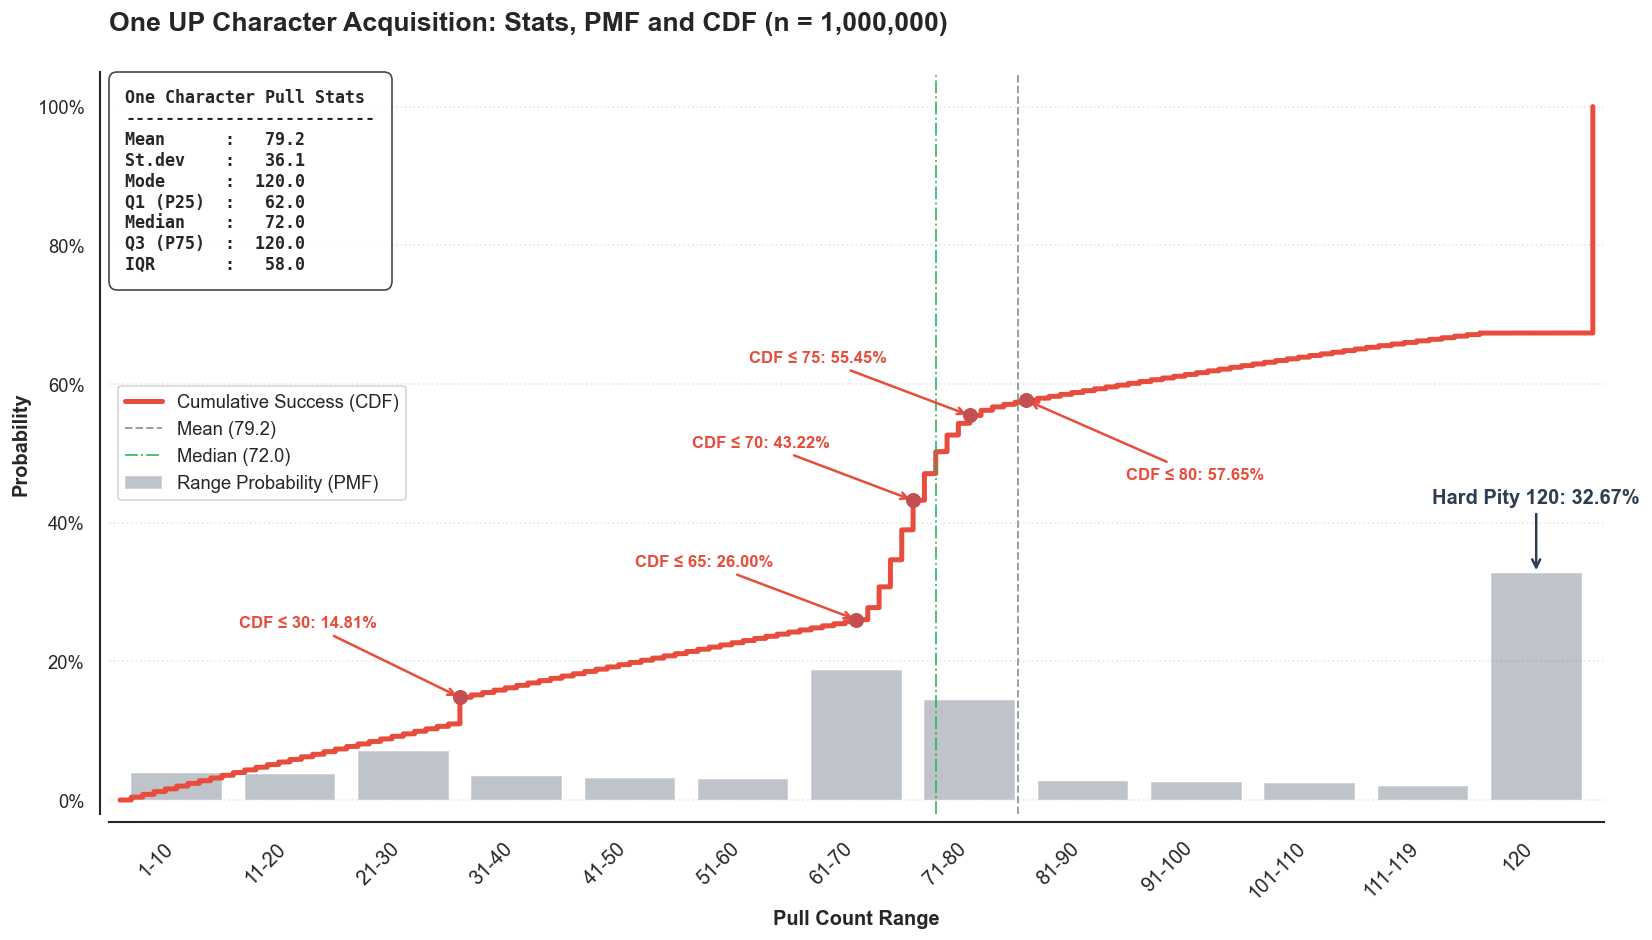

=== Layered Insight Analysis ===
1. Ratio WITHIN 120-pull wall (1 UP + 1 Non-UP at exactly 120 pulls): 63.68%
2. Ratio ACROSS entire dataset (1 UP + 1 Non-UP at exactly 120 pulls): 20.80%
3. Ratio of SUFFOCATION ZONE (101-120 pulls with exactly 1 UP + 1 Non-UP) across entire dataset: 24.10%
✅ Figure saved successfully


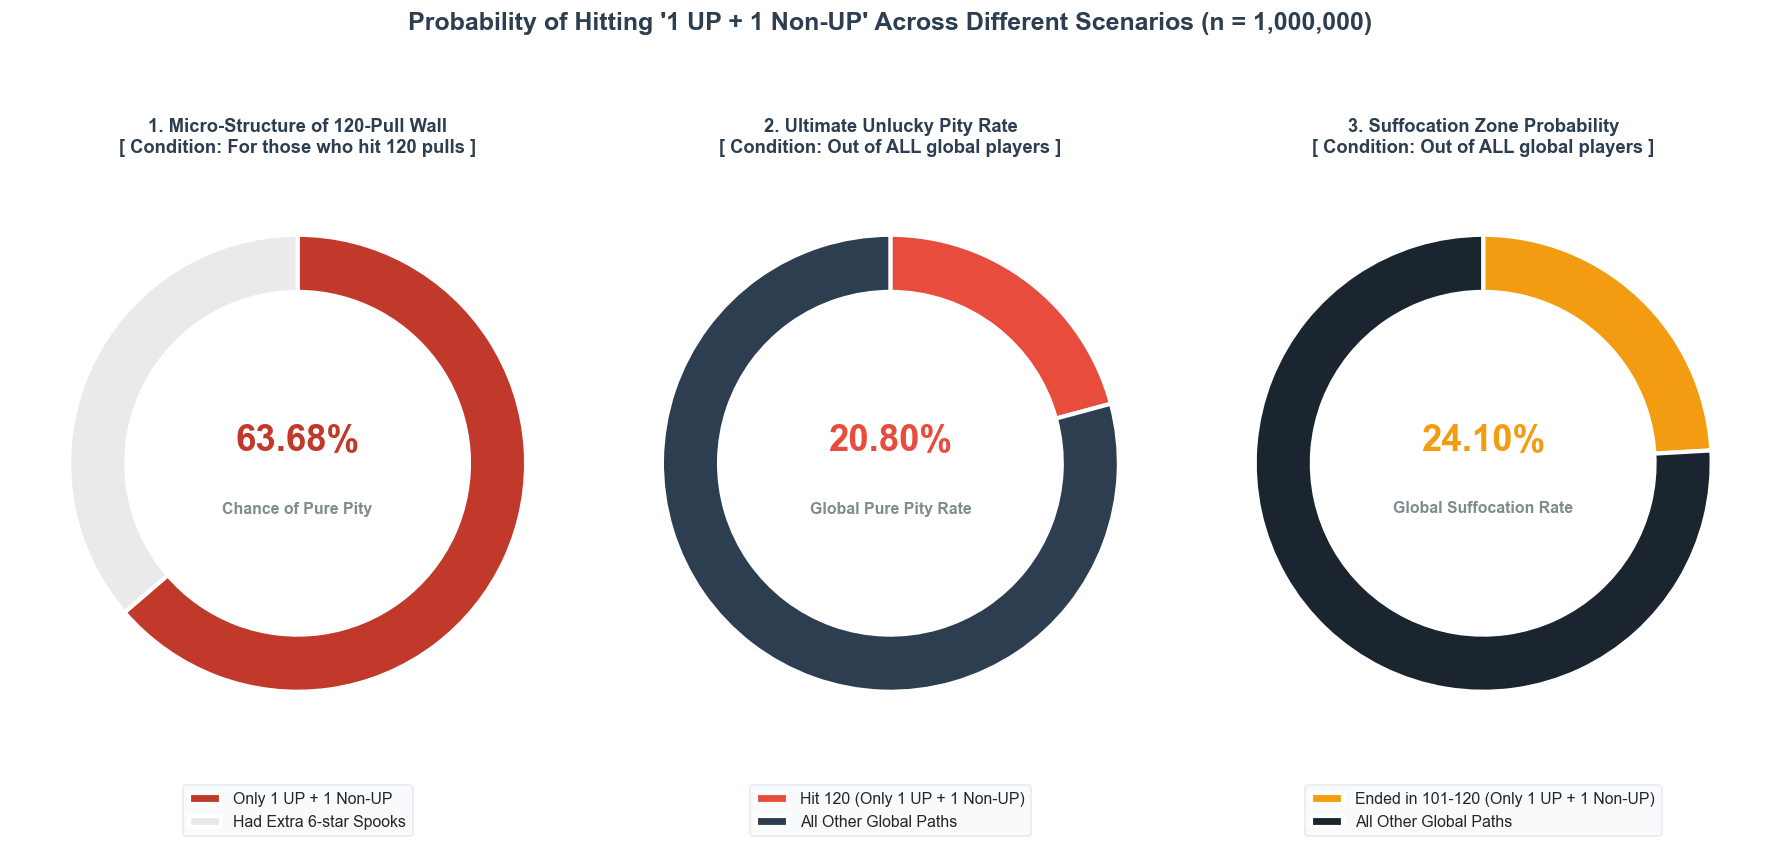

In [2]:
# --- Load and Apply Endgame Conversion Rules ---
single_char_path = DATA_DIR / 'sim_char_single.csv'
df_char, trials = get_char_sim_path_and_transform_quota(single_char_path)

# --- 1. Data Categorization & Cumulative Probability Processing ---
pulls_data = df_char['num_pulls_for_char']

# Define custom boundaries to isolate the final 120th pull
bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 119, 120]

# Build custom labels matching the custom bins
labels = []
for i in range(len(bins)-1):
    if bins[i+1] == 120:
        labels.append("120") # Isolated hard pity wall
    else:
        labels.append(f"{bins[i]+1}-{bins[i+1]}")

# Categorize data into corresponding ranges using pd.cut
df_char['range_cat'] = pd.cut(pulls_data, bins=bins, labels=labels)

# Calculate percentage for each range (PMF)
pmf_values = df_char['range_cat'].value_counts(normalize=True).sort_index() * 100

# --- 2. Plotting Settings ---
fig, ax = plt.subplots(figsize=(14, 8))
x_pos = np.arange(len(labels))

# 2.1 PMF Bar Chart (Represents range probability)
ax.bar(x_pos, pmf_values, color=COLOR_PMF, alpha=0.3, edgecolor='white', linewidth=1, label='Range Probability (PMF)')

# 2.2 CDF Cumulative Curve with Non-uniform Axis Mapping (Using Interpolation)
sorted_data = np.sort(pulls_data)
cdf_x_raw = np.insert(sorted_data, 0, 0)
cdf_y_raw = np.insert(np.arange(1, len(sorted_data) + 1) / float(len(sorted_data)) * 100, 0, 0)

# Build a mapping anchor table to translate real pull counts to categorical x-coordinates
# Real pull counts at bin boundaries: [0, 10, 20, ..., 110, 119, 120]
# map to bar chart coordinates:      [-0.5, 0.5, 1.5, ..., 10.5, 11.5, 12.5]
xp_anchors = np.array(bins)
fp_anchors = np.arange(len(bins)) - 0.5

# Perform linear interpolation to get a perfectly aligned CDF curve
cdf_x_mapped = np.interp(cdf_x_raw, xp_anchors, fp_anchors)
ax.plot(cdf_x_mapped, cdf_y_raw, color=COLOR_CDF, linewidth=3, label='Cumulative Success (CDF)')

# 2.3 Added Professional Visual Anchors: Mean and Median Vlines
mean_val = pulls_data.mean()
median_val = pulls_data.median()

# Map Mean and Median dynamically using our non-uniform anchor system
mean_x_mapped = np.interp(mean_val, xp_anchors, fp_anchors)
median_x_mapped = np.interp(median_val, xp_anchors, fp_anchors)

ax.axvline(mean_x_mapped, color='#7f8c8d', linestyle='--', linewidth=1.2, alpha=0.8, label=f'Mean ({mean_val:.1f})')
ax.axvline(median_x_mapped, color='#27ae60', linestyle='-.', linewidth=1.2, alpha=0.8, label=f'Median ({median_val:.1f})')

# 2.4 Statistical Parameters (Top-Left Box)
stats = {
    'Mean': mean_val,
    'St.dev': pulls_data.std(),
    'Mode': pulls_data.mode()[0],
    'Q1 (P25)': pulls_data.quantile(0.25),
    'Median': median_val,
    'Q3 (P75)': pulls_data.quantile(0.75),
    'IQR': pulls_data.quantile(0.75) - pulls_data.quantile(0.25)
}
stats_text = "\n".join([f"{k:10}: {v:>6.1f}" for k, v in stats.items()])
at = AnchoredText(f"One Character Pull Stats\n{'-'*25}\n{stats_text}",
                  prop=dict(size=10, family='monospace', fontweight='bold'), 
                  frameon=True, loc='upper left', pad=0.5)
at.patch.set_boxstyle("round,pad=0.5")
at.patch.set_alpha(0.8)
ax.add_artist(at)

# 2.5 Specific Annotations
# (1) PMF Annotation: Pinpointed to look at the custom 120 hard pity bar (the 13th bar -> index 12)
target_idx_final = 12 
val_120 = pmf_values.iloc[target_idx_final]
ax.annotate(f'Hard Pity 120: {val_120:.2f}%', 
            xy=(target_idx_final, val_120), 
            xytext=(0, 40), textcoords="offset points", 
            arrowprops=dict(arrowstyle='->', color=COLOR_PMF, lw=1.5),
            ha='center', va='bottom', fontweight='bold', color=COLOR_PMF)

# (2) CDF Annotation List [30, 65, 80] using offset points to guarantee bulletproof arrow directions
cdf_targets = [30, 65, 70, 75, 80]

for target in cdf_targets:
    cdf_val = (pulls_data <= target).mean() * 100
    
    # Map marker dots perfectly onto the curve using the interpolation map
    marker_x = np.interp(target, xp_anchors, fp_anchors)
    ax.plot(marker_x, cdf_val, 'ro', markersize=8, zorder=5)
    
    # Custom pixel-offset layout based on the target location
    if target == 30 :
        x_pt, y_pt = -50, 40
        ha_dir, va_dir = 'right', 'bottom'
    elif target == 65 or target == 70 or target == 75:
        # Pushed to Top-Left because 65 is likely on the super steep soft-pity cliff
        x_pt, y_pt = -50, 30
        ha_dir, va_dir = 'right', 'bottom'
    else:
        # Target 80: Bottom-Right to use open space after the cliff
        x_pt, y_pt = 60, -40
        ha_dir, va_dir = 'left', 'top'
        
    ax.annotate(f'CDF ≤ {target}: {cdf_val:.2f}%', 
                xy=(marker_x, cdf_val), 
                xytext=(x_pt, y_pt), textcoords="offset points",
                arrowprops=dict(arrowstyle='->', color=COLOR_CDF, lw=1.5),
                fontweight='bold', color=COLOR_CDF, fontsize=10,
                ha=ha_dir, va=va_dir)

# 2.6 Formatting & Detail Optimization
plt.title(f'One UP Character Acquisition: Stats, PMF and CDF (n = {trials})', fontsize=16, fontweight='bold', loc='left', pad=25)
ax.set_xlabel('Pull Count Range', fontsize=12, fontweight='bold')
ax.set_ylabel('Probability', fontsize=12, fontweight='bold')

ax.set_ylim(-2, 105)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

# Set limits covering exactly all 13 custom ranges
ax.set_xlim(-0.6, len(labels) - 0.4) 

# Fixed legend location
ax.legend(loc='center left', frameon=True)

# Disable trim to maintain unbroken axis line on the bottom-left corner
sns.despine(offset=5, trim=False)

# Apply rotated ticks beautifully (rotated 45 deg because we have 13 custom text labels now)
ax.set_xticks(x_pos)
plt.xticks(x_pos, labels, rotation=45, fontsize=12, ha='right')

plt.grid(axis='y', linestyle=':', alpha=0.5)
plt.tight_layout()
save_fig("mode_1_char_single_combo.png")
plt.show()

# =========================================================================
# 1. Stratified Filtering & Precise Metric Calculations
# =========================================================================
# Core condition A: Ultimate Unlucky Target (Exactly 120 pulls, 1 UP, 1 Non-UP Only)
unlucky_count = len(df_char.loc[
    (df_char['num_pulls_for_char'] == 120) & 
    (df_char['up_6_star_char'] == 1) & 
    (df_char['non_6_star_char'] == 1)
])

# Core condition B: Suffocation Zone Target (101 to 120 pulls, 1 UP, 1 Non-UP Only)
suffocation_zone_count = len(df_char.loc[
    (df_char['num_pulls_for_char'] >= 101) & 
    (df_char['num_pulls_for_char'] <= 120) & 
    (df_char['up_6_star_char'] == 1) & 
    (df_char['non_6_star_char'] == 1)
])

# Base Denominators
total_120_players = len(df_char.loc[df_char['num_pulls_for_char'] == 120])
total_all_players = len(df_char)

# Calculate dynamic ratios exactly matching your logic
ratio_within_120_wall = (unlucky_count / total_120_players) * 100 if total_120_players > 0 else 0
ratio_across_all_data = (unlucky_count / total_all_players) * 100 if total_all_players > 0 else 0
ratio_suffocation_zone = (suffocation_zone_count / total_all_players) * 100 if total_all_players > 0 else 0

print(f"=== Layered Insight Analysis ===")
print(f"1. Ratio WITHIN 120-pull wall (1 UP + 1 Non-UP at exactly 120 pulls): {ratio_within_120_wall:.2f}%")
print(f"2. Ratio ACROSS entire dataset (1 UP + 1 Non-UP at exactly 120 pulls): {ratio_across_all_data:.2f}%")
print(f"3. Ratio of SUFFOCATION ZONE (101-120 pulls with exactly 1 UP + 1 Non-UP) across entire dataset: {ratio_suffocation_zone:.2f}%")

# =========================================================================
# 2. Straightforward Text Mapping (Intuitive Probability Focus)
# =========================================================================
# Chart 1: Given you hit 120 pulls, what is the chance of having ZERO extra 6-stars?
data_p1 = [ratio_within_120_wall, 100 - ratio_within_120_wall]
colors_p1 = ['#c0392b', '#eaeaea'] 
labels_p1 = ['Only 1 UP + 1 Non-UP', 'Had Extra 6-star Spooks']

# Chart 2: Out of ALL players, what is the chance of hitting 120 pulls with ZERO extra 6-stars?
data_p2 = [ratio_across_all_data, 100 - ratio_across_all_data]
colors_p2 = ['#e74c3c', '#2c3e50'] 
labels_p2 = ['Hit 120 (Only 1 UP + 1 Non-UP)', 'All Other Global Paths']

# Chart 3: Out of ALL players, what is the chance of ending in 101-120 pulls with ZERO extra 6-stars?
data_p3 = [ratio_suffocation_zone, 100 - ratio_suffocation_zone]
colors_p3 = ['#f39c12', '#1a252f'] 
labels_p3 = ['Ended in 101-120 (Only 1 UP + 1 Non-UP)', 'All Other Global Paths']

plot_configs = [
    (data_p1, colors_p1, labels_p1, ratio_within_120_wall, "Chance of Pure Pity"),
    (data_p2, colors_p2, labels_p2, ratio_across_all_data, "Global Pure Pity Rate"),
    (data_p3, colors_p3, labels_p3, ratio_suffocation_zone, "Global Suffocation Rate")
]

# Using titles as the descriptive framework so the chart speaks for itself
titles = [
    "1. Micro-Structure of 120-Pull Wall\n[ Condition: For those who hit 120 pulls ]",
    "2. Ultimate Unlucky Pity Rate\n[ Condition: Out of ALL global players ]",
    "3. Suffocation Zone Probability\n[ Condition: Out of ALL global players ]"
]

# =========================================================================
# 3. Canvas Blueprint & Intuitive Donut Render Engine
# =========================================================================
fig, axs = plt.subplots(1, 3, figsize=(15, 6.5), dpi=120)
donut_width = 0.25  

for i, (data, colors, legend_labels, target_metric, center_label) in enumerate(plot_configs):
    wedges, _ = axs[i].pie(
        data, 
        colors=colors, 
        startangle=90,
        counterclock=False,  
        wedgeprops=dict(width=donut_width, edgecolor='w', linewidth=2.5)
    )
    
    # --- Center KPI Metrics Text Injection ---
    axs[i].text(
        0, 0.1, f"{target_metric:.2f}%", 
        ha='center', va='center', 
        fontsize=22, weight='bold', color=colors[0]
    )
    axs[i].text(
        0, -0.2, center_label, 
        ha='center', va='center', 
        fontsize=9.5, weight='bold', color='#7f8c8d'
    )
    
    # --- Simplified Legend Layout Positioning ---
    axs[i].legend(
        wedges, legend_labels,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.05),  
        frameon=True,
        facecolor='#f8f9fa',
        edgecolor='#e2e8f0',
        fontsize=9.5
    )
    
    axs[i].set_title(titles[i], fontsize=11, weight='bold', color='#2c3e50', pad=15)

plt.suptitle(f"Probability of Hitting '1 UP + 1 Non-UP' Across Different Scenarios (n = {trials})", fontsize=15, weight='bold', color='#2c3e50', y=1.05)
plt.tight_layout()
save_fig("mode_1_char_single_structure.png")
plt.show()

## [MODE-2] 2. Headhunting Banner - Full Potential Analysis & Charts / 滿潛限定角色模擬結果之統計與視覺化圖表

**🇺🇸 English Version**
***

**📊 Full Potential Distribution & Cumulative Probability Analysis (PMF & CDF)**
* **Data Ingestion & Uniform Binning**:
  * Reads `sim_char_full_potential.csv` and uses `pd.cut` to categorize pull counts into 20 uniform ranges of 60 pulls each (`1-60`, `61-120`, ..., `1141-1200`), spanning up to 1200 pulls to capture full potential distribution behaviors.
* **PMF & Categorical Coordinate Linear Mapping**:
  * **Probability Mass Function (PMF)**: Displays individual range probabilities via bar chart (`#2c3e50` Midnight Blue).
  * **Coordinate Axis Mapping**: Maps continuous pull counts to discrete categorical X-axis positions using the linear scaling function `(pull_count / 60.0) - 0.5`, enabling seamless overlay of the continuous Cumulative Distribution Function curve (CDF, `#e74c3c` Soft Red).
* **Statistical Metrics & Dynamic Visual Callouts**:
  * **Summary Metrics Panel (Upper-Left)**: Uses a monospace text block to display Mean, Standard Deviation, Mode, Median (P50), Q1 (P25), Q3 (P75), and Interquartile Range (IQR).
  * **Central Tendency Reference Lines**: Dynamically plots vertical dashed lines for Mean (gray) and Median (green) translated into X-axis categorical coordinates.
  * **Peak & Milestone Annotations**: 
    * Automatically pinpoints and annotates the PMF **Peak Range** with highest probability density.
    * Highlights key CDF milestone targets (`120`, `240`, `360`, `480`, `600`, `720`, `960` pulls), using dynamic precision formatting (up to 4 decimal places for extreme boundary values like $\ge 99.9\%$ or $\le 0.1\%$) and custom offset directions for arrow readability.

---

**🇹🇼 繁體中文版**
***

**📊 滿潛抽卡分佈與累積機率複合圖表 (PMF & CDF Analysis)**
* **數據載入與等寬分組 (Binning)**：
  * 讀取 `sim_char_full_potential.csv` 資料集，透過 `pd.cut` 將總抽數劃分為 20 個以 60 抽為梯度的等寬區間（`1-60`, `61-120`, ..., `1141-1200`），涵蓋高達 1200 抽的完整滿潛拉鋸光譜。
* **機率分佈與類別座標線性映射 (PMF & CDF Mapping)**：
  * **機率質量函數 (PMF)**：以柱狀圖（Midnight Blue `#2c3e50`）呈現各 60 抽區間的單點獲取機率。
  * **類別座標映射**：利用公式 `(抽數 / 60.0) - 0.5` 將連續抽數精準對齊至類別 X 軸，使累積機率曲線 (CDF, Soft Red `#e74c3c`) 能完美疊加於區間柱狀圖之上。
* **統計指標與動態圖表標註**：
  * **統計參數框 (Upper-Left Box)**：即時計算並以等寬字型呈現 Mean（平均數）、St.dev（標準差）、Mode（眾數）、Median（中位數/P50）、Q1 (P25)、Q3 (P75) 及 IQR（四分位距）。
  * **中心趨勢垂直線**：動態將平均數（灰虛線）與中位數（綠點虛線）映射繪製於圖面上。
  * **峰值與里程碑標註 (Annotations)**：
    * **PMF 峰值標註**：自動定位並標註單點機率最高的「機率峰值區間 (Peak Range)」。
    * **CDF 里程碑標註**：針對關鍵里程碑抽數 (`120`, `240`, `360`, `480`, `600`, `720`, `960` 抽) 繪製動態紅點與引導箭頭；極限邊界值（$\ge 99.9\%$ 或 $\le 0.1\%$）自動開啟 4 位小數動態精準度顯示，確保數據不被四捨五入所掩蓋。

✅ Figure saved successfully


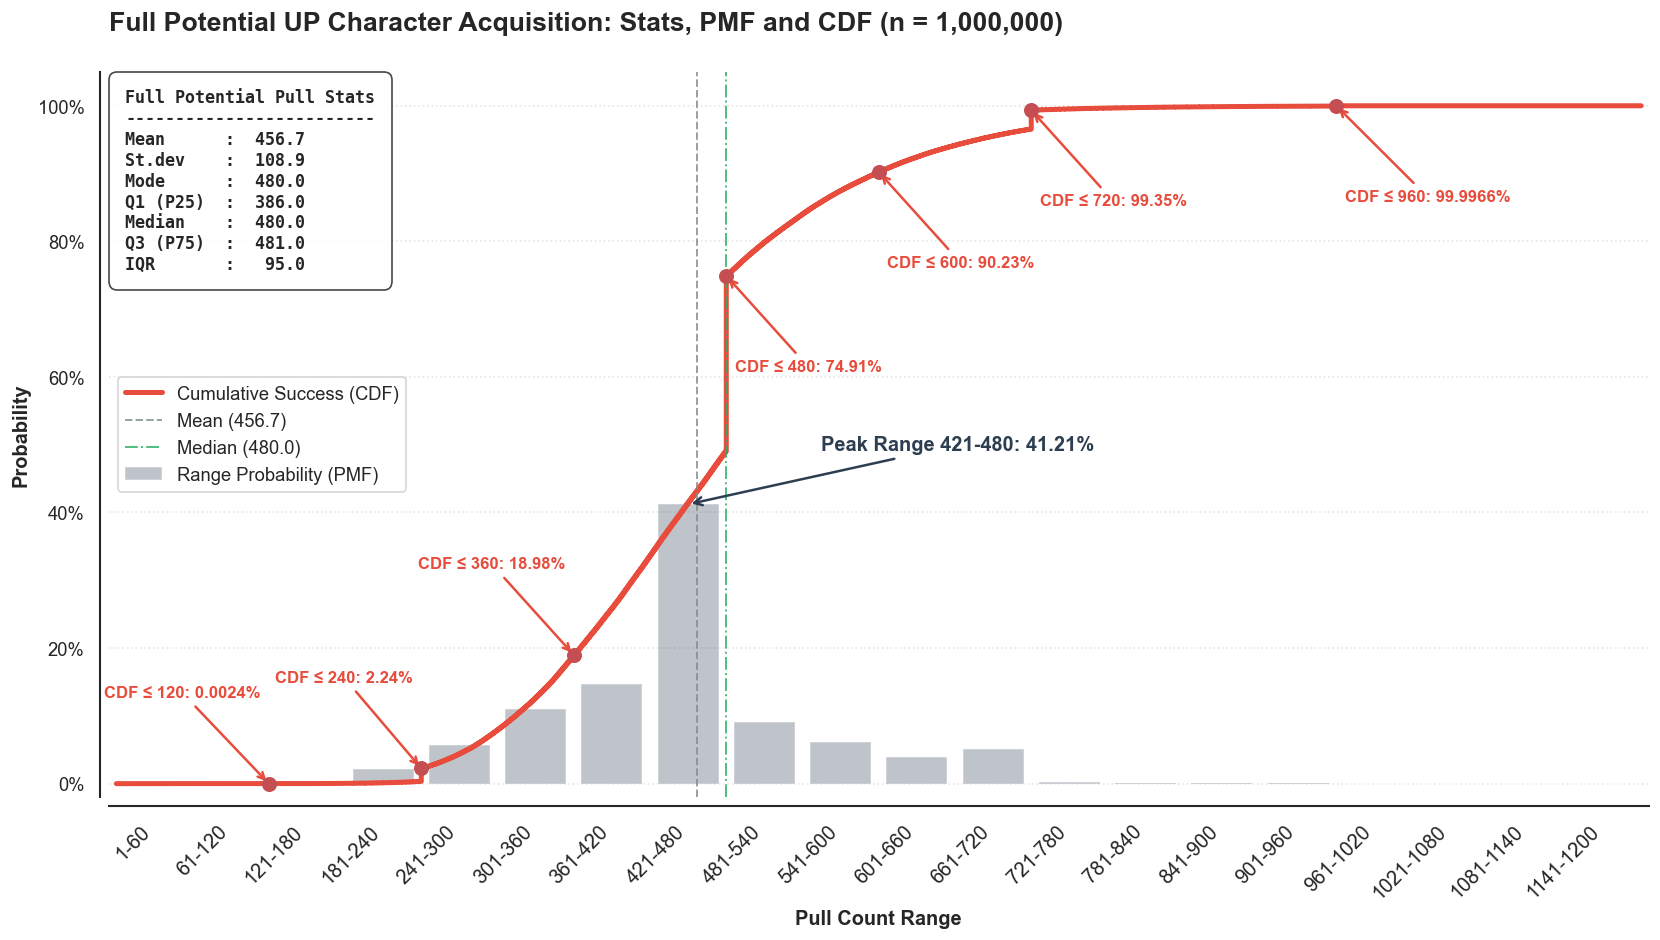

In [3]:
# --- Load and Apply Endgame Conversion Rules ---
FP_char_path = DATA_DIR / 'sim_char_full_potential.csv'
df_FPchar, trials = get_char_sim_path_and_transform_quota(FP_char_path)

# --- 1. Data Categorization & Cumulative Probability Processing ---
pulls_data = df_FPchar['num_pulls_for_char']

# Define boundaries and labels for 1-60, 61-120, ..., 1141-1200 (20 intervals)
bins = np.arange(0, 1201, 60) 
labels = [f"{i+1}-{i+60}" for i in bins[:-1]]

# Categorize data into corresponding 60-pull ranges using pd.cut
df_FPchar['range_cat'] = pd.cut(pulls_data, bins=bins, labels=labels)

# Calculate percentage for each range (PMF)
pmf_values = df_FPchar['range_cat'].value_counts(normalize=True).sort_index() * 100

# --- 2. Plotting Settings ---
fig, ax = plt.subplots(figsize=(14, 8))
x_pos = np.arange(len(labels))

# 2.1 PMF Bar Chart (Represents range probability)
ax.bar(x_pos, pmf_values, color=COLOR_PMF, alpha=0.3, edgecolor='white', linewidth=1, label='Range Probability (PMF)')

# 2.2 CDF Cumulative Curve (Starting from origin)
sorted_data = np.sort(pulls_data)
cdf_x_raw = np.insert(sorted_data, 0, 0)
cdf_y_raw = np.insert(np.arange(1, len(sorted_data) + 1) / float(len(sorted_data)) * 100, 0, 0)

# Map raw pull counts to categorical axis coordinates
cdf_x_mapped = (cdf_x_raw / 60.0) - 0.5
ax.plot(cdf_x_mapped, cdf_y_raw, color=COLOR_CDF, linewidth=3, label='Cumulative Success (CDF)')

# 2.3 Added Professional Visual Anchors: Mean and Median Vlines
mean_val = pulls_data.mean()
median_val = pulls_data.median()

# Map these exact pull counts onto our categorical X-axis template
mean_x_mapped = (mean_val / 60.0) - 0.5
median_x_mapped = (median_val / 60.0) - 0.5

# Plot vertical dashed lines for central tendency markers
ax.axvline(mean_x_mapped, color='#7f8c8d', linestyle='--', linewidth=1.2, alpha=0.8, label=f'Mean ({mean_val:.1f})')
ax.axvline(median_x_mapped, color='#27ae60', linestyle='-.', linewidth=1.2, alpha=0.8, label=f'Median ({median_val:.1f})')

# 2.4 Statistical Parameters (Top-Left Box) - Added IQR for better dispersion context
stats = {
    'Mean': mean_val,
    'St.dev': pulls_data.std(),
    'Mode': pulls_data.mode()[0],
    'Q1 (P25)': pulls_data.quantile(0.25),
    'Median': median_val,
    'Q3 (P75)': pulls_data.quantile(0.75),
    'IQR': pulls_data.quantile(0.75) - pulls_data.quantile(0.25)
}
stats_text = "\n".join([f"{k:10}: {v:>6.1f}" for k, v in stats.items()])
at = AnchoredText(f"Full Potential Pull Stats\n{'-'*25}\n{stats_text}",
                  prop=dict(size=10, family='monospace', fontweight='bold'), 
                  frameon=True, loc='upper left', pad=0.5)
at.patch.set_boxstyle("round,pad=0.5")
at.patch.set_alpha(0.8)
ax.add_artist(at)

# 2.5 Specific Annotations
# (1) PMF Annotation: Peak Range
target_idx_peak = pmf_values.argmax()
val_peak = pmf_values.iloc[target_idx_peak]
label_peak = labels[target_idx_peak]

ax.annotate(f'Peak Range {label_peak}: {val_peak:.2f}%', 
            xy=(target_idx_peak, val_peak), 
            xytext=(80, 30), textcoords="offset points",
            arrowprops=dict(arrowstyle='->', color=COLOR_PMF, lw=1.5),
            ha='left', va='bottom', fontweight='bold', color=COLOR_PMF)

# (2) CDF Annotation List (Target 480 now successfully merged into the bottom-right group)
cdf_targets = [120, 240, 360, 480, 600, 720, 960]

for target in cdf_targets:
    cdf_val = (pulls_data <= target).mean() * 100
    marker_x = (target / 60.0) - 0.5
    ax.plot(marker_x, cdf_val, 'ro', markersize=8, zorder=5)
    
    # Clean two-way branching logic based on your request
    if target == 120 or target == 240 or target == 360:
        # Strictly Top-Left
        x_pt, y_pt = -5, 50
        ha_dir, va_dir = 'right', 'bottom'
    else:
        # Targets 480, 600, 720, 960: Strictly Bottom-Right to capture open real estate
        x_pt, y_pt = 5, -50
        ha_dir, va_dir = 'left', 'top'
        
    if (99.9 <= cdf_val < 100) or (0 < cdf_val <= 0.1):
        precision = 4
    else:
        precision = 2
        
    ax.annotate(f'CDF ≤ {target}: {cdf_val:.{precision}f}%', 
                xy=(marker_x, cdf_val), 
                xytext=(x_pt, y_pt), textcoords="offset points",
                arrowprops=dict(arrowstyle='->', color=COLOR_CDF, lw=1.5),
                fontweight='bold', color=COLOR_CDF, fontsize=10,
                ha=ha_dir, va=va_dir)

# 2.6 Formatting & Detail Optimization
plt.title(f'Full Potential UP Character Acquisition: Stats, PMF and CDF (n = {trials})', fontsize=16, fontweight='bold', loc='left', pad=25)
ax.set_xlabel('Pull Count Range', fontsize=12, fontweight='bold')
ax.set_ylabel('Probability', fontsize=12, fontweight='bold')

ax.set_ylim(-2, 105)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlim(-0.6, len(labels) - 0.4) 

# Fixed legend location
ax.legend(loc='center left', frameon=True)

# Maintain unbroken axis line on the bottom-left corner
sns.despine(offset=5, trim=False)

# Re-apply rotated ticks beautifully
ax.set_xticks(x_pos)
plt.xticks(x_pos, labels, rotation=45, fontsize=12, ha='right')

plt.grid(axis='y', linestyle=':', alpha=0.5)
plt.tight_layout()
save_fig("mode_2_char_full_pot_combo.png")
plt.show()

## [MODE-3] 3. Special Analysis - Arsenal Ticket & Arsenal Issues Conversion Charts / 武庫配額獲取與武器申領次數轉換模擬結果之統計與視覺化圖表

**🇺🇸 English Version**
***

**🔄 Data Pipeline & Cross-Notebook Alignment**
* **Upstream Data Source**: This mode visualizes the output generated by Mode 3 in **[simulation.ipynb](./simulation.ipynb)** (`sim_fixed_{N}_pulls.csv`). It maps player pulling budgets into tangible weapon extraction resources, bridging Headhunting and Arsenal systems.
* **Single Source of Truth (`pull_nodes`)**: The grid architecture is dynamically driven by the `pull_nodes` array (defaults to `[80, 120, 240, 480, 720, 960]`). Ensure that the node array configured here **perfectly matches** the one executed in `simulation.ipynb`.

**📊 Dynamic Subplot Layout & Endgame Conversion Model**
* **Flexible Grid Geometry**: Calculates rows dynamically using `math.ceil(len(pull_nodes) / 3)` with a fixed 3-column layout. The canvas automatically reflows, scales, and cleans up unused axes regardless of array modifications.
* **Unit Conversion Formula**: Evaluates token outputs via the pipeline helper `get_char_sim_path_and_transform_quota()`, converting raw `weapon_quota` into exact **Arsenal Issues** using the standard game constant:
  $$\text{Arsenal Issues} = \frac{\text{weapon\_quota}}{1980}$$
* **Probability Density & Statistical Overlay (KDE & Stats)**:
  * Overlays KDE smooth curves on probability density histograms (`stat="density"`, 40 bins) to show distribution shifts across budget tiers.
  * Features monospace metric cards for each node displaying Mean, St.dev, Mode, Q1 (P25), Median (P50), Q3 (P75), and IQR.
  * Includes Mean (red dashed line) and Median (green dotted line) visual anchors, with an extra +25% X-axis padding to ensure legend clarity.

---

**🇹🇼 繁體中文版**
***

**🔄 資料管道與跨檔案對齊 (Data Pipeline)**
* **上游資料來源**：本模式專門將 **[simulation.ipynb](./simulation.ipynb)** 中 Mode 3 所產出的 CSV 資料集 (`sim_fixed_{N}_pulls.csv`) 進行數據載入與視覺化，將玩家的角色尋訪預算轉化為具體的武器申領資源。
* **單一真值來源 (`pull_nodes`)**：畫布結構由 `pull_nodes` 陣列（預設為 `[80, 120, 240, 480, 720, 960]`）動態驅動。請確保此處設定的節點陣列與 `simulation.ipynb` 中執行的陣列**完全一致**。

**📊 動態網格佈局與副產物換算模型**
* **彈性網格幾何 (Dynamic Grid Geometry)**：採用 3 欄式設計並透過 `math.ceil` 動態計算所需列數。無論未來增減多少抽數節點，畫布皆能自動延伸、對齊並隱藏多餘的空子圖。
* **單位轉換數學模型**：透過副產物轉換管道 `get_char_sim_path_and_transform_quota()` 讀取數據，並依據遊戲內固定匯率將原始 `weapon_quota`（武庫配額）轉換為 **Arsenal Issues（武器申領次數）**：
  $$\text{武器申領次數 (Arsenal Issues)} = \frac{\text{武庫配額 (weapon\_quota)}}{1980}$$
* **機率密度與統計量視圖 (KDE & Histogram)**：
  * 結合核密度估計曲線 (KDE, 40 bins) 與機率密度直方圖，展示不同預算下武器申領次數的分佈轉移。
  * 每個子圖皆包含獨立的等寬字型統計面板（涵蓋 Mean, St.dev, Mode, Q1, Median, Q3, IQR）。
  * 標註平均數（紅虛線）與中位數（綠點線）參考線，並自動將 X 軸右側延伸 25% 空間以防止圖例遮擋。

✅ Figure saved successfully


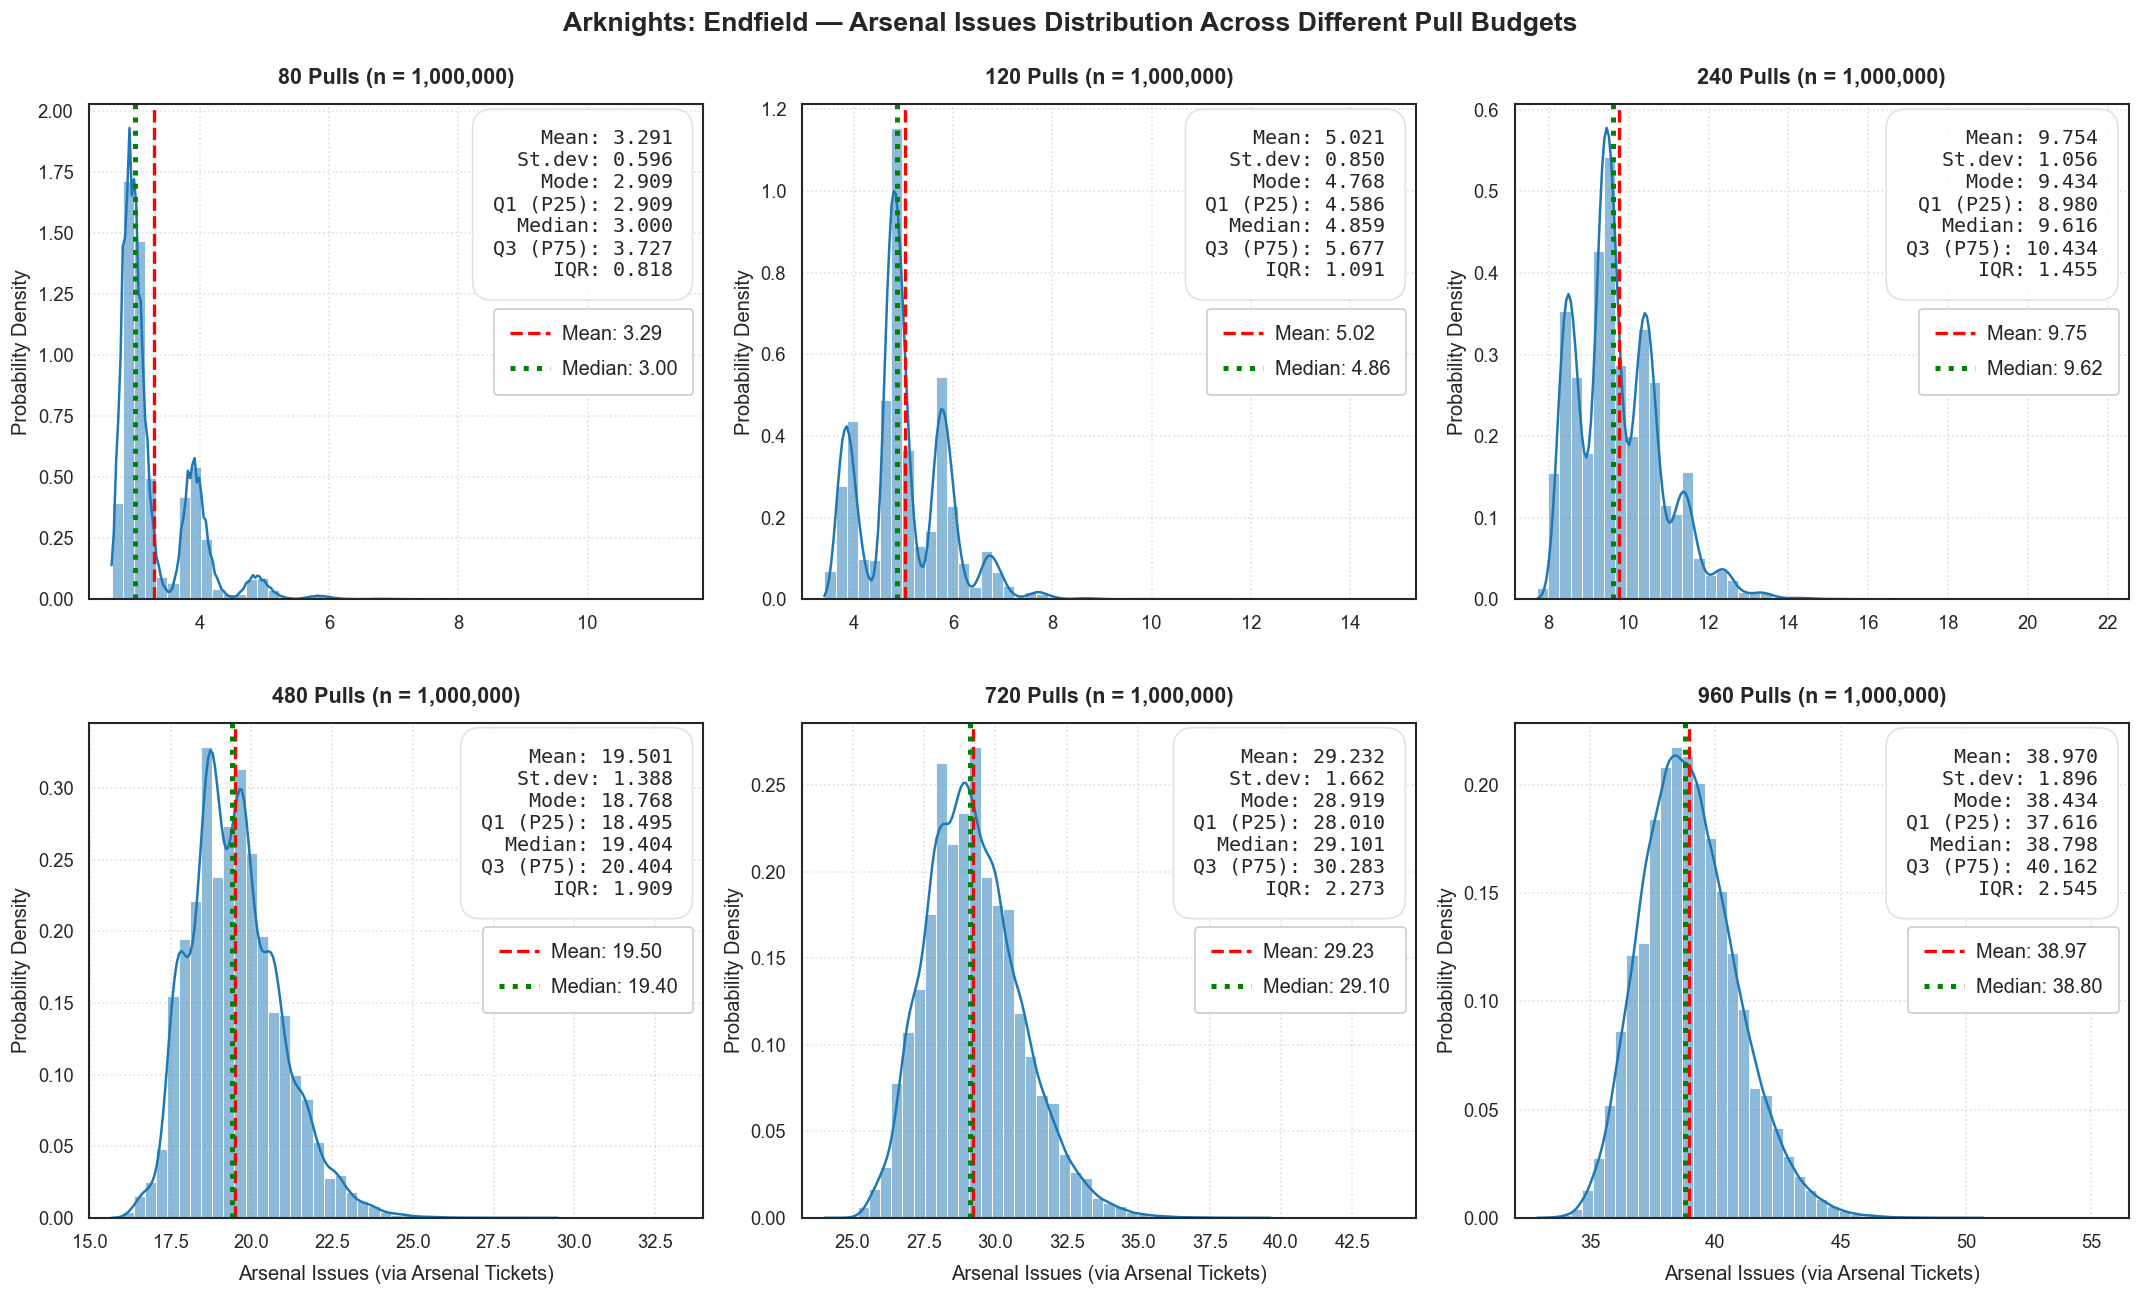

In [4]:
# --- 1. Single Source of Truth Configuration ---
# Anyone can freely add '30' or other nodes here; layout adapts automatically.
pull_nodes = [80, 120, 240, 480, 720, 960]

# Grid Layout Calculation: fixed to 3 columns, rows scale dynamically
cols = 3
rows = math.ceil(len(pull_nodes) / cols)

# Initialize dynamic canvas grid based on computed dimensions
fig, axes = plt.subplots(
    nrows=rows, ncols=cols, figsize=(cols * 6, rows * 5.5), sharey=False
)

# Flatten axes array for safe 1D iteration across any grid configuration
axes_flat = axes.flatten() if len(pull_nodes) > 1 else [axes]

# --- 2. Iterative Pipeline Loop ---
for i, nodes in enumerate(pull_nodes):
    ax = axes_flat[i]
    file_path = DATA_DIR / f"sim_fixed_{nodes}_pulls.csv"

    # Defensive check if the CSV node is missing
    if not file_path.exists():
        ax.text(
            0.5,
            0.5,
            f"Missing Simulation Data\nNode: {nodes} Pulls",
            ha="center",
            va="center",
            color="red",
            fontsize=12,
        )
        ax.set_axis_off()
        continue

    # Load and apply endgame conversion rules via your existing pipeline helper
    df_fixed, trials = get_char_sim_path_and_transform_quota(file_path)

    # Convert weapon quota data to Arsenal Issues (Single Source of Truth transformation)
    pulls_data = df_fixed["weapon_quota"] / 1980

    # Calculate specific statistical indicators
    mean_val = pulls_data.mean()
    median_val = pulls_data.median()
    mode_series = pulls_data.mode()
    mode_val = mode_series[0] if not mode_series.empty else mean_val
    q1 = pulls_data.quantile(0.25)
    q3 = pulls_data.quantile(0.75)
    iqr = q3 - q1
    std_val = pulls_data.std()

    # Draw histogram and KDE line using your professional styling
    sns.histplot(
        pulls_data,
        kde=True,
        ax=ax,
        color="#1f77b4",
        edgecolor="white",
        linewidth=0.5,
        stat="density",
        bins=40,
    )

    # Draw prominent reference lines (Mean: 2.0 dashed, Median: 3.0 dotted)
    ax.axvline(
        mean_val,
        color="red",
        linestyle="--",
        linewidth=2.0,
        label=f"Mean: {mean_val:.2f}",
    )
    ax.axvline(
        median_val,
        color="green",
        linestyle=":",
        linewidth=3.0,
        label=f"Median: {median_val:.2f}",
    )

    # --- 3. Dynamic X-axis Limit Tuning (Optimized for Center Right Legend) ---
    x_min, x_max = ax.get_xlim()
    ax.set_xlim(x_min, x_max + (x_max - x_min) * 0.25)

    # --- 4. Construct Descriptive Statistical Text Box ---
    stats_text = (
        f"Mean: {mean_val:.3f}\n"
        f"St.dev: {std_val:.3f}\n"
        f"Mode: {mode_val:.3f}\n"
        f"Q1 (P25): {q1:.3f}\n"
        f"Median: {median_val:.3f}\n"
        f"Q3 (P75): {q3:.3f}\n"
        f"IQR: {iqr:.3f}"
    )

    ax.text(
        0.95,
        0.95,
        stats_text,
        transform=ax.transAxes,
        fontsize=12,
        fontfamily="monospace",
        verticalalignment="top",
        horizontalalignment="right",
        bbox=dict(
            boxstyle="round,pad=1", facecolor="white", alpha=0.85, edgecolor="#dddddd"
        ),
    )

    # --- 5. Axes and Subplot Aesthetics Fine-Tuning ---
    ax.set_title(
        f"{nodes} Pulls (n = {len(pulls_data):,})", fontsize=13, fontweight="bold", pad=12
    )

    # Clean Layout: Dynamically only show X-label on the bottom row of active plots
    if i >= (rows - 1) * cols:
        ax.set_xlabel(
            "Arsenal Issues (via Arsenal Tickets)", fontsize=12, labelpad=8
        )
    else:
        ax.set_xlabel("", fontsize=10)

    ax.set_ylabel("Probability Density", fontsize=12)
    ax.grid(True, linestyle=":", alpha=0.6)

    # Set legend to center right with a slightly transparent frame
    ax.legend(
        loc="center right",
        fontsize=12,
        framealpha=1,
        borderpad=0.8,
        labelspacing=0.8,
        handletextpad=0.6,
    )

# --- 6. Clean up redundant empty subplots if the grid isn't perfectly filled ---
for empty_idx in range(len(pull_nodes), len(axes_flat)):
    axes_flat[empty_idx].set_axis_off()

# --- 7. Global Layout Optimization and Rendering ---
plt.suptitle(
    "Arknights: Endfield — Arsenal Issues Distribution Across Different Pull Budgets",
    fontsize=16,
    fontweight="bold",
    y=0.98,
)
plt.tight_layout()
plt.subplots_adjust(top=0.91, hspace=0.25)
save_fig("mode_3_arsenal_issues_grid.png")
plt.show()

## [MODE-4] 4. Arsenal Issues - First Acquisition Analysis & Charts / 首次獲得機率提升武器模擬結果之統計與視覺化圖表

**🇺🇸 English Version**
***

**📊 Discrete Weapon Acquisition Distribution & CDF Alignment (PMF & CDF)**
* **Data Ingestion & Discrete Binning**:
  * Reads `sim_weapon_single.csv` and uses `pd.cut` with discrete boundaries `[0, 1, 2, ..., 8]` to map raw weapon pulls into 8 exact discrete count bins (`"1"`, `"2"`, ..., `"8"`).
* **PMF & Discrete Coordinate Linear Mapping**:
  * **Probability Mass Function (PMF)**: Displays single-entry acquisition probabilities via discrete bar charts (`COLOR_PMF` at 30% opacity).
  * **Coordinate Axis Mapping**: Utilizes linear interpolation (`np.interp`) against anchor tables (`xp_anchors` and `fp_anchors`) to smoothly map raw discrete pull data to categorical X-coordinates, enabling continuous CDF curve (`COLOR_CDF`) overlays.
* **Statistical Metrics & Tactical Annotations**:
  * **Summary Metrics Panel (Upper-Left Box)**: Uses `AnchoredText` to display monospace summary statistics, including Mean, Standard Deviation, Mode, Q1 (P25), Median (P50), Q3 (P75), and Interquartile Range (IQR).
  * **Central Tendency Reference Lines**: Maps Mean (gray dashed line) and Median (green dash-dot line) into categorical X-axis positions dynamically.
  * **Mechanics Pinpointing**:
    * **Hard Pity Spike**: Automatically annotates the probability spike at the 8th weapon acquisition (Index 7), highlighting the guaranteed pity wall.
    * **Milestone Targets**: Plots key milestone markers (`≤ 1`, `≤ 2`, `≤ 4`, `≤ 6` issues) with precision dynamic arrows and custom offsets to reveal early-acquisition vs. late-pity probability curves.

---

**🇹🇼 繁體中文版**
***

**📊 武器申領離散分佈與累積機率複合圖表 (PMF & CDF Analysis)**
* **數據載入與離散分組 (Discrete Binning)**：
  * 讀取 `sim_weapon_single.csv` 資料集，透過 `pd.cut` 與離散邊界 `[0, 1, 2, ..., 8]` 將抽取次數精準歸類為 8 個離散類別（`"1"`, `"2"`, ..., `"8"`）。
* **離散座標映射與圖表疊加 (Discrete Interpolation Mapping)**：
  * **機率質量函數 (PMF)**：以離散柱狀圖（`COLOR_PMF` 透明度 30%）呈現單次武器申領獲得目標武器的機率分佈。
  * **座標插值映射**：利用線性插值 (`np.interp`) 與對齊錨點表 (`xp_anchors` 與 `fp_anchors`)，將原始離散次數精準轉換至類別 X 軸，實現連續累積機率曲線 (CDF, `COLOR_CDF`) 與柱狀圖的完美疊加。
* **統計指標與關鍵機制標註**：
  * **統計參數框 (Upper-Left AnchoredText)**：以等寬字型呈現包含 Mean（平均數）、St.dev（標準差）、Mode（眾數）、Q1 (P25)、Median（中位數）、Q3 (P75) 及 IQR（四分位距）的統計面板。
  * **中心趨勢垂直線**：透過插值動態將平均數（灰色虛線）與中位數（綠色點虛線）繪製於圖面上。
  * **武器機制重點標註 (Annotations)**：
    * **第 8 次硬保底牆**：自動定位並標註第 8 次申領（Index 7）的 PMF 突異點，精準還原武器系統的硬保底機制。
    * **關鍵里程碑標註**：針對關鍵申領次數 (`≤ 1`, `≤ 2`, `≤ 4`, `≤ 6` 次) 繪製動態紅點與引導箭頭，展示前期獲取率與後期保底收斂曲線。

✅ Figure saved successfully


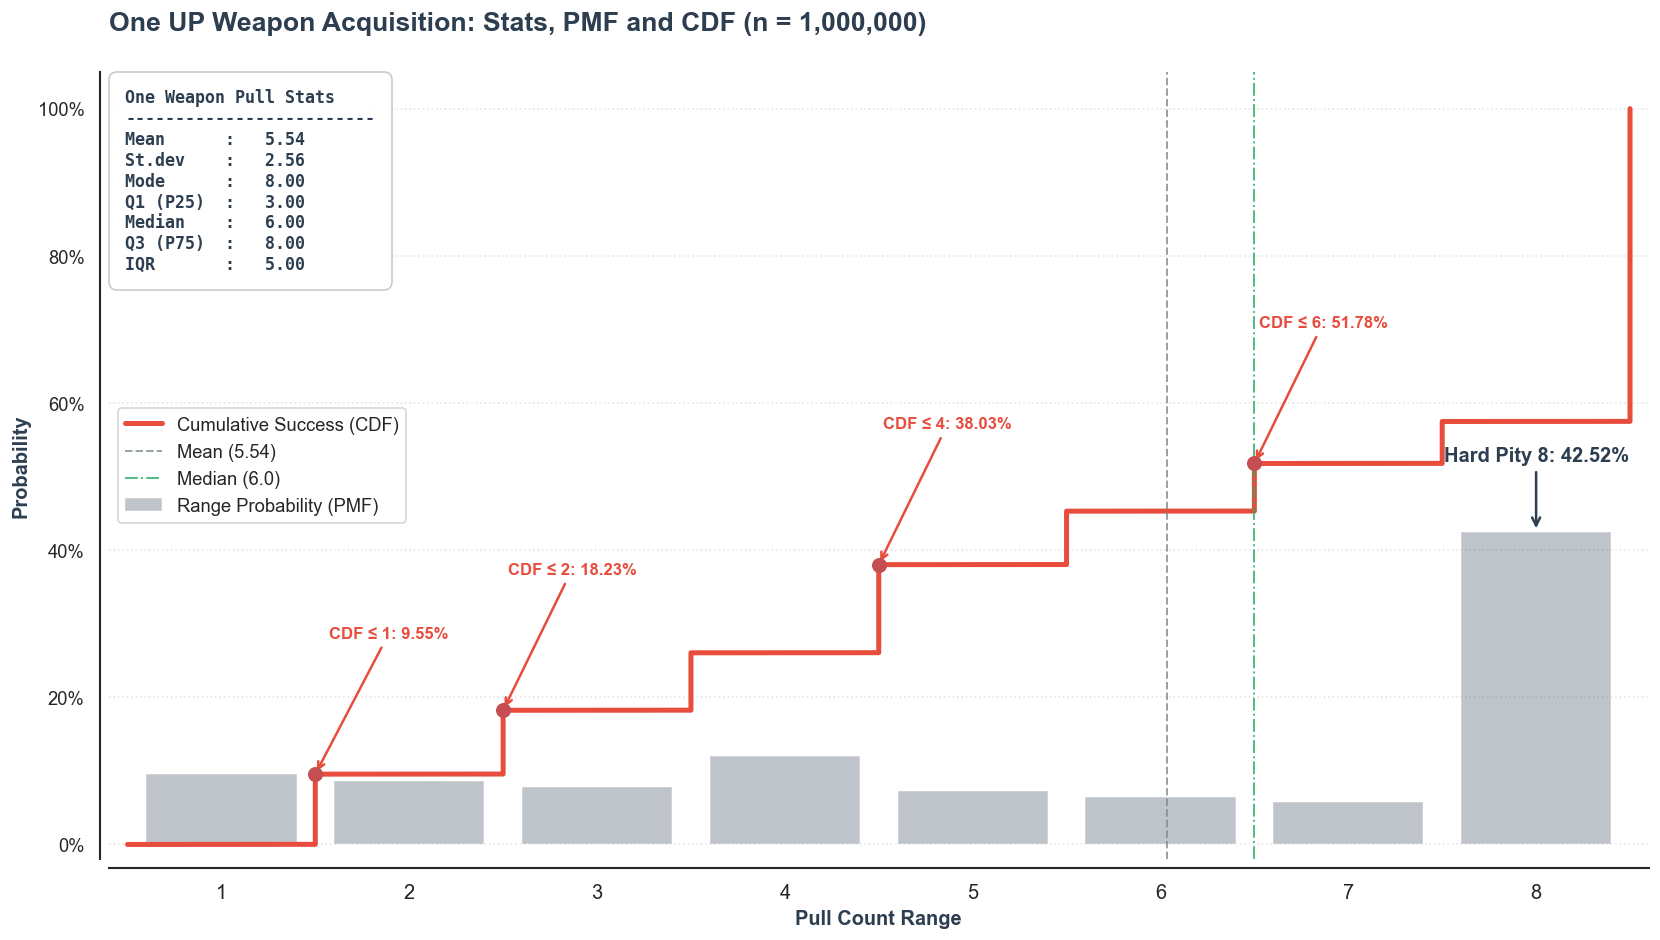

In [5]:
# =========================================================================
# 1. Load Weapon Simulated Production Data
# =========================================================================
single_weapon_path = DATA_DIR / 'sim_weapon_single.csv'
df_weapon = pd.read_csv(single_weapon_path)
pulls_data = df_weapon['num_pulls_for_weapon']
trials = len(pulls_data)

# Define discrete boundaries to isolate the final 8th weapon acquisition
bins = [0, 1, 2, 3, 4, 5, 6, 7, 8]

# Build custom labels matching the discrete bins (1, 2, ..., 7, 8)
labels = []
for i in range(len(bins)-1):
    if bins[i+1] == 8:
        labels.append("8")  # Isolated hard pity weapon wall
    else:
        labels.append(f"{bins[i+1]}")

# Categorize data into corresponding discrete acquisitions using pd.cut
df_weapon['range_cat'] = pd.cut(pulls_data, bins=bins, labels=labels)

# Calculate percentage for each single acquisition entry (PMF)
pmf_values = df_weapon['range_cat'].value_counts(normalize=True).sort_index() * 100

# =========================================================================
# 2. Plotting Settings (All-in-One Layout Synchronization)
# =========================================================================
fig, ax = plt.subplots(figsize=(14, 8))
x_pos = np.arange(len(labels))

# 2.1 PMF Bar Chart (Represents single entry acquisition probability)
ax.bar(x_pos, pmf_values, color=COLOR_PMF, alpha=0.3, edgecolor='white', linewidth=1, label='Range Probability (PMF)')

# 2.2 CDF Cumulative Curve with Non-uniform Axis Mapping (Using Interpolation)
sorted_data = np.sort(pulls_data)
cdf_x_raw = np.insert(sorted_data, 0, 0)
cdf_y_raw = np.insert(np.arange(1, len(sorted_data) + 1) / float(len(sorted_data)) * 100, 0, 0)

# Build a mapping anchor table to translate real weapon acquisitions to categorical x-coordinates
xp_anchors = np.array(bins)
fp_anchors = np.arange(len(bins)) - 0.5

# Perform linear interpolation to get a perfectly aligned CDF curve
cdf_x_mapped = np.interp(cdf_x_raw, xp_anchors, fp_anchors)
ax.plot(cdf_x_mapped, cdf_y_raw, color=COLOR_CDF, linewidth=3, label='Cumulative Success (CDF)')

# 2.3 Professional Visual Anchors: Mean and Median Vlines
mean_val = pulls_data.mean()
median_val = pulls_data.median()

# Map Mean and Median dynamically using our discrete anchor system
mean_x_mapped = np.interp(mean_val, xp_anchors, fp_anchors)
median_x_mapped = np.interp(median_val, xp_anchors, fp_anchors)

ax.axvline(mean_x_mapped, color='#7f8c8d', linestyle='--', linewidth=1.2, alpha=0.8, label=f'Mean ({mean_val:.2f})')
ax.axvline(median_x_mapped, color='#27ae60', linestyle='-.', linewidth=1.2, alpha=0.8, label=f'Median ({median_val:.1f})')

# 2.4 Statistical Parameters (Top-Left Clean Box Alignment)
stats = {
    'Mean': mean_val,
    'St.dev': pulls_data.std(),
    'Mode': pulls_data.mode()[0],
    'Q1 (P25)': pulls_data.quantile(0.25),
    'Median': median_val,
    'Q3 (P75)': pulls_data.quantile(0.75),
    'IQR': pulls_data.quantile(0.75) - pulls_data.quantile(0.25)
}
stats_text = "\n".join([f"{k:10}: {v:>6.2f}" for k, v in stats.items()])
at = AnchoredText(f"One Weapon Pull Stats\n{'-'*25}\n{stats_text}",
                  prop=dict(size=10, family='monospace', fontweight='bold', color='#2c3e50'), 
                  frameon=True, loc='upper left', pad=0.5)
at.patch.set_boxstyle("round,pad=0.5")
at.patch.set_edgecolor('#bdc3c7')
at.patch.set_alpha(0.85)
ax.add_artist(at)

# 2.5 Specific Annotations (Pinpointed to look at Weapon Mechanics)
# (1) PMF Annotation: Hard Pity at 8th weapon acquisition (Index 7)
target_idx_final = 7 
val_8 = pmf_values.iloc[target_idx_final]
ax.annotate(f'Hard Pity 8: {val_8:.2f}%', 
            xy=(target_idx_final, val_8), 
            xytext=(0, 40), textcoords="offset points", 
            arrowprops=dict(arrowstyle='->', color=COLOR_PMF, lw=1.5),
            ha='center', va='bottom', fontweight='bold', color=COLOR_PMF)

# (2) CDF Specific Key Annotations [1, 2, 4, 6] representing crucial milestones
cdf_targets = [1, 2, 4, 6]

for target in cdf_targets:
    cdf_val = (pulls_data <= target).mean() * 100
    
    # Map marker dots perfectly onto the curve using the interpolation map
    marker_x = np.interp(target, xp_anchors, fp_anchors)
    ax.plot(marker_x, cdf_val, 'ro', markersize=8, zorder=5)
    
    # Precise pixel-offset layout tailored for weapon distribution curve space
    # if target == 1:
    #     x_pt, y_pt = 40, -30
    #     ha_dir, va_dir = 'left', 'top'
    if target in cdf_targets:
        x_pt, y_pt = 80, 80
        ha_dir, va_dir = 'right', 'bottom'
    # else:  # Target 6
    #     x_pt, y_pt = 50, -40
    #     ha_dir, va_dir = 'left', 'top'
        
    ax.annotate(f'CDF ≤ {target}: {cdf_val:.2f}%', 
                xy=(marker_x, cdf_val), 
                xytext=(x_pt, y_pt), textcoords="offset points",
                arrowprops=dict(arrowstyle='->', color=COLOR_CDF, lw=1.5),
                fontweight='bold', color=COLOR_CDF, fontsize=10,
                ha=ha_dir, va=va_dir)

# 2.6 Formatting & Detail Optimization
plt.title(f'One UP Weapon Acquisition: Stats, PMF and CDF (n = {trials:,})', fontsize=16, fontweight='bold', loc='left', pad=25, color='#2c3e50')
ax.set_xlabel('Pull Count Range', fontsize=12, fontweight='bold', color='#2c3e50')
ax.set_ylabel('Probability', fontsize=12, fontweight='bold', color='#2c3e50')

ax.set_ylim(-2, 105)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

# Set limits covering exactly all 8 discrete entries
ax.set_xlim(-0.6, len(labels) - 0.4) 

# Fixed legend location
ax.legend(loc='center left', frameon=True)

# Disable trim to maintain unbroken axis line on the bottom-left corner
sns.despine(offset=5, trim=False)

# Clean horizontal tick positioning without text rotation
ax.set_xticks(x_pos)
plt.xticks(x_pos, labels, rotation=0, fontsize=12, ha='center')

plt.grid(axis='y', linestyle=':', alpha=0.5)
plt.tight_layout()
save_fig("mode_4_weapon_single_combo.png")
plt.show()

## [MODE-5] 5. Arsenal Issues - Full Potential Analysis & Charts / 滿潛機率提升武器模擬結果之統計與視覺化圖表

**🇺🇸 English Version**
***

**📊 Non-Uniform Binning & Pity Wall Isolation (Full Potential Weapon PMF & CDF)**
* **Data Ingestion & Non-Uniform Binning**:
  * Reads `sim_weapon_full_potential.csv` and uses `pd.cut` with non-uniform boundaries `[0, 17, 18, 21, ..., 82]`.
  * Groups standard pull counts into 3-step range buckets (e.g., `"19-21"`), while explicitly isolating hard pity milestones into single bars (`"18"`, `"34"`, `"50"`, `"66"`, `"82"`).
* **PMF & Custom Grid Axis Mapping**:
  * **Probability Mass Function (PMF)**: Displays range probabilities across non-uniform buckets via bar charts (`COLOR_PMF` at 30% opacity).
  * **Coordinate Axis Mapping**: Uses linear interpolation (`np.interp`) against anchor tables (`xp_anchors` and `fp_anchors`) to map continuous CDF curve (`COLOR_CDF`) smoothly over custom-width X-coordinates without distortion.
* **Statistical Metrics & Tactical Annotations**:
  * **Summary Metrics Panel (Upper-Left Box)**: Uses `AnchoredText` to display monospace summary statistics, including Mean, Standard Deviation, Mode, Q1 (P25), Median (P50), Q3 (P75), and Interquartile Range (IQR).
  * **Central Tendency Reference Lines**: Maps Mean (gray dashed line) and Median (palette-coded dash-dot line) into categorical X-axis positions dynamically.
  * **Mechanics Pinpointing**:
    * **Key Milestone Markers**: Plots red dots and directional arrows at critical cumulative thresholds (`≤ 18`, `≤ 34`, `≤ 50`, `≤ 66`) with custom text offsets to prevent overlapping.
    * **Rotated Labels**: Tilts category X-axis labels by 45 degrees (`rotation=45`) for effortless reading across 26 non-uniform bins.

---

**🇹🇼 繁體中文版**
***

**📊 非均勻分區與保底牆隔離圖表 (滿潛武器 PMF & CDF Analysis)**
* **數據載入與非均勻分組 (Non-Uniform Binning)**：
  * 讀取 `sim_weapon_full_potential.csv` 資料集，透過 `pd.cut` 與非均勻邊界 `[0, 17, 18, 21, ..., 82]` 進行分類。
  * 一般申領次數以每 3 次合併為一組（如 `"19-21"`），同時將關鍵保底牆獨立為單一柱狀（`"18"`, `"34"`, `"50"`, `"66"`, `"82"`），讓保底效應一眼可見。
* **分區座標映射與圖表疊加 (Custom Grid Interpolation)**：
  * **機率質量函數 (PMF)**：以柱狀圖（`COLOR_PMF` 透明度 30%）呈現不同次數區間達成滿潛武器的機率分佈。
  * **座標插值映射**：利用線性插值 (`np.interp`) 與對齊錨點表 (`xp_anchors` 與 `fp_anchors`)，將連續累積機率曲線 (CDF, `COLOR_CDF`) 完美貼合於非等寬的柱狀圖上，避免圖形變形。
* **統計指標與關鍵機制標註**：
  * **統計參數框 (Upper-Left AnchoredText)**：以等寬字型呈現包含 Mean（平均數）、St.dev（標準差）、Mode（眾數）、Q1 (P25)、Median（中位數）、Q3 (P75) 及 IQR（四分位距）的統計面板。
  * **中心趨勢垂直線**：透過插值動態將平均數（灰色虛線）與中位數（主題顏色點虛線）繪製於圖面上。
  * **武器機制重點標註 (Annotations)**：
    * **關鍵里程碑標註**：針對關鍵累積保底點 (`≤ 18`, `≤ 34`, `≤ 50`, `≤ 66` 次) 繪製紅點與引導箭頭，並微調位置避免文字重疊。
    * **刻度標籤優化**：將 26 個分區標籤旋轉 45 度 (`rotation=45`)，確保圖表下方的文字清晰易讀。

✅ Figure saved successfully


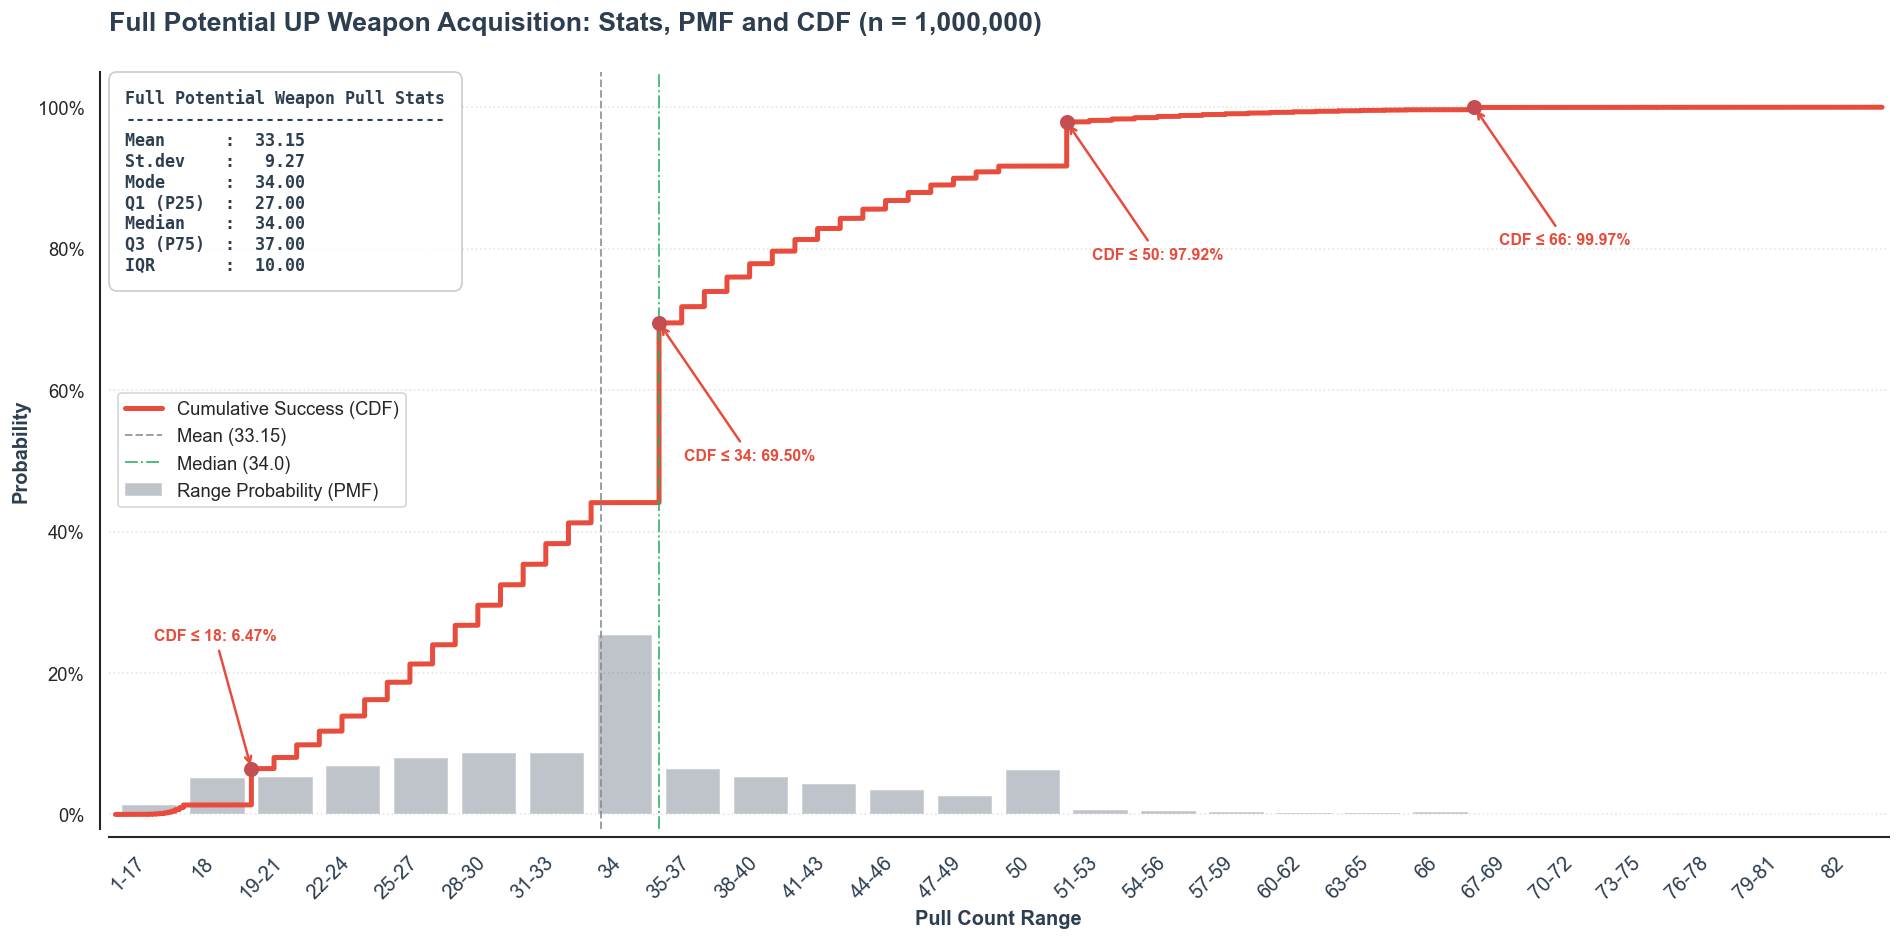

In [6]:
# =========================================================================
# 1. Load Weapon Simulated Production Data
# =========================================================================
FP_weapon_path = DATA_DIR / 'sim_weapon_full_potential.csv'
df_FPweapon = pd.read_csv(FP_weapon_path)
pulls_data = df_FPweapon['num_pulls_for_weapon']
trials = len(pulls_data)

# =========================================================================
# 2. Setup Non-Uniform Custom Bins (Grouping 3 pulls & Isolating Pity Walls)
# =========================================================================
# Define specialized custom boundaries isolating critical pity walls: 18, 34, 50, 66, 82
bins = [
    0, 17, 18, 21, 24, 27, 30, 33, 34, 37, 40, 43, 46, 49, 50, 
    53, 56, 59, 62, 65, 66, 69, 72, 75, 78, 81, 82
]

# Build custom text labels mapping the segmented structure
labels = []
for i in range(len(bins)-1):
    start = bins[i] + 1
    end = bins[i+1]
    if start == end:
        labels.append(f"{end}")  # Isolated milestones (18, 34, 50, 66, 82)
    else:
        labels.append(f"{start}-{end}")  # Combined 3-step range buckets

# Categorize into custom range segments using your variables
df_FPweapon['range_cat'] = pd.cut(pulls_data, bins=bins, labels=labels)
pmf_values = df_FPweapon['range_cat'].value_counts(normalize=True).sort_index() * 100

# =========================================================================
# 3. Plotting Layout (Non-Uniform Interval Mapping Engine)
# =========================================================================
fig, ax = plt.subplots(figsize=(16, 8))
x_pos = np.arange(len(labels))

# 3.1 PMF Segmented Bar Chart (Using your globally configured COLOR_PMF)
ax.bar(x_pos, pmf_values, color=COLOR_PMF, alpha=0.3, edgecolor='white', linewidth=1, label='Range Probability (PMF)')

# 3.2 CDF Interpolation Over Non-Uniform Grid Matrix
sorted_data = np.sort(pulls_data)
cdf_x_raw = np.insert(sorted_data, 0, 0)
cdf_y_raw = np.insert(np.arange(1, len(sorted_data) + 1) / float(len(sorted_data)) * 100, 0, 0)

xp_anchors = np.array(bins)
fp_anchors = np.arange(len(bins)) - 0.5
cdf_x_mapped = np.interp(cdf_x_raw, xp_anchors, fp_anchors)
ax.plot(cdf_x_mapped, cdf_y_raw, color=COLOR_CDF, linewidth=3, label='Cumulative Success (CDF)')

# 3.3 Visual Anchors Mapping Mean/Median onto Categorical Space
mean_val = pulls_data.mean()
median_val = pulls_data.median()

mean_x_mapped = np.interp(mean_val, xp_anchors, fp_anchors)
median_x_mapped = np.interp(median_val, xp_anchors, fp_anchors)

ax.axvline(mean_x_mapped, color='#7f8c8d', linestyle='--', linewidth=1.2, alpha=0.8, label=f'Mean ({mean_val:.2f})')
ax.axvline(median_x_mapped, color=PALETTE_QUANTILES[0], linestyle='-.', linewidth=1.2, alpha=0.8, label=f'Median ({median_val:.1f})')

# 3.4 Statistical Parameters Box Alignment (Using your custom stats layout)
stats = {
    'Mean': mean_val,
    'St.dev': pulls_data.std(),
    'Mode': pulls_data.mode()[0],
    'Q1 (P25)': pulls_data.quantile(0.25),
    'Median': median_val,
    'Q3 (P75)': pulls_data.quantile(0.75),
    'IQR': pulls_data.quantile(0.75) - pulls_data.quantile(0.25)
}
stats_text = "\n".join([f"{k:10}: {v:>6.2f}" for k, v in stats.items()])
at = AnchoredText(f"Full Potential Weapon Pull Stats\n{'-'*32}\n{stats_text}",
                  prop=dict(size=10, family='monospace', fontweight='bold', color=COLOR_PMF), 
                  frameon=True, loc='upper left', pad=0.5)
at.patch.set_boxstyle("round,pad=0.5")
at.patch.set_edgecolor('#bdc3c7')
at.patch.set_alpha(0.85)
ax.add_artist(at)

# 3.5 Target Milestone Pinpoint Markings locked on [18, 34, 50, 66, 82]
cdf_targets = [18, 34, 50, 66]

for target in cdf_targets:
    cdf_val = (pulls_data <= target).mean() * 100
    marker_x = np.interp(target, xp_anchors, fp_anchors)
    ax.plot(marker_x, cdf_val, 'ro', markersize=8, zorder=5)
    
    # Custom pixel-offset layout based on the target location to avoid overlap
    if target == 18:
        x_pt, y_pt = 15, 75
        ha_dir, va_dir = 'right', 'bottom'
    else:
        x_pt, y_pt = 15, -75
        ha_dir, va_dir = 'left', 'top'
        
    ax.annotate(f'CDF ≤ {target}: {cdf_val:.2f}%', 
                xy=(marker_x, cdf_val), 
                xytext=(x_pt, y_pt), textcoords="offset points",
                arrowprops=dict(arrowstyle='->', color=COLOR_CDF, lw=1.5),
                fontweight='bold', color=COLOR_CDF, fontsize=9.5,
                ha=ha_dir, va=va_dir)

# 3.6 Interface Details Configuration
plt.title(f'Full Potential UP Weapon Acquisition: Stats, PMF and CDF (n = {trials:,})', fontsize=16, fontweight='bold', loc='left', pad=25, color=COLOR_PMF)
ax.set_xlabel('Pull Count Range', fontsize=12, fontweight='bold', color=COLOR_PMF)
ax.set_ylabel('Probability', fontsize=12, fontweight='bold', color=COLOR_PMF)

ax.set_ylim(-2, 105)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlim(-0.6, len(labels) - 0.4) 
ax.legend(loc='center left', frameon=True)
sns.despine(offset=5, trim=False)

# Horizontal ticks formatting with a clean 45-degree tilt
ax.set_xticks(x_pos)
plt.xticks(x_pos, labels, rotation=45, fontsize=12, ha='right', color=COLOR_PMF)

plt.grid(axis='y', linestyle=':', alpha=0.5)
plt.tight_layout()
save_fig("mode_5_weapon_full_pot_combo.png")
plt.show()